<a href="https://colab.research.google.com/github/Devil-Gaming-Studios/Data_analysis_battery/blob/main/VoltRelay_Battery_Swap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VoltRelay Energy — Battery-Swap Network Analysis
### Gradient Learnings Data Analytics Hackathon

**Role:** Data Analyst supporting VoltRelay's operations and customer experience teams.

**Objective:** Determine how the network performed over Jan 2024–Jun 2025, what factors are
associated with service failures, rider churn, and eroding margins, where performance varies most
across stations/geography/equipment/partner segment, and what VoltRelay should prioritize next.

**Contents**
1. Data Understanding
2. Data Cleaning
3. Building the Analysis-Ready Table
4. Exploratory Data Analysis
5. Core Q1 — Network Performance Over Time
6. Core Q2 — Service Failures & Customer Experience
7. Core Q3 — Station & Geographic Patterns
8. Core Q4 — Battery & Equipment Performance
9. Core Q5 — Pricing & Partner Economics
10. Core Q6 — Root Cause Analysis of Retention
11. Optional Deep-Dives — Budget Decision & Anomalies
12. Key Findings & Recommendations

> Written to be memory-efficient (explicit dtypes, categoricals, freeing intermediates) so it runs
> comfortably in a standard Colab runtime despite `swap_events` having ~3.9M rows.


In [14]:
# ---- Setup ----
import pandas as pd, numpy as np, gc, os
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# >>> EDIT to the folder containing the 8 dataset files <<<
DATA_DIR = '/content/drive/MyDrive/'  # e.g. '/content/drive/MyDrive/voltrelay_hackathon'

def data_path(fname):
    """Return path to a dataset file, accepting either .csv or .csv.gz,
       and also handling 'Copy of' prefix."""
    possible_fnames = [fname, 'Copy of ' + fname]
    for p_fname in possible_fnames:
        p_csv = os.path.join(DATA_DIR, p_fname)
        p_gz = p_csv + '.gz'
        if os.path.exists(p_csv):
            return p_csv
        elif os.path.exists(p_gz):
            return p_gz
    raise FileNotFoundError(f'Could not find {fname} (or .gz, or with "Copy of" prefix) in {DATA_DIR}')

print('Colab:', IN_COLAB, '| DATA_DIR:', os.path.abspath(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | DATA_DIR: /content/drive/MyDrive


## 1. Data Understanding

We load all eight tables. `swap_events` (~3.9M rows) and `station_hourly_status` (~1.5M rows) use
explicit dtypes (categoricals for repeated strings, float32 for measurements) to keep memory
reasonable — this keeps `swap_events` under ~500MB in memory instead of well over 1GB.

In [15]:
# ---- Small reference tables ----
riders = pd.read_csv(data_path('riders.csv'), parse_dates=['signup_date'])
batteries = pd.read_csv(data_path('batteries.csv'),
                         parse_dates=['manufacture_date', 'commission_date', 'retired_date'])
stations = pd.read_csv(data_path('stations.csv'),
                        parse_dates=['commissioned_date', 'decommissioned_date',
                                     'firmware_updated_date', 'competitor_within_1_5km_since'])
fleet = pd.read_csv(data_path('fleet_partners.csv'),
                     parse_dates=['contract_start_date', 'amendment_date'])
city_ctx = pd.read_csv(data_path('city_daily_context.csv'), parse_dates=['date'])
tickets = pd.read_csv(data_path('support_tickets.csv'), parse_dates=['created_ts'])

for name, df in [('riders', riders), ('batteries', batteries), ('stations', stations),
                  ('fleet_partners', fleet), ('city_daily_context', city_ctx),
                  ('support_tickets', tickets)]:
    print(f'{name}: {df.shape}')

riders: (20000, 12)
batteries: (6500, 13)
stations: (152, 22)
fleet_partners: (12, 12)
city_daily_context: (3282, 12)
support_tickets: (44000, 12)


In [16]:
# ---- station_hourly_status (1.49M rows) ----
station_hourly_dtypes = {
    'station_id': 'category', 'telemetry_status': 'category',
    'charged_2w_avg': 'float32', 'charged_2w_min': 'float32', 'charged_3w_min': 'float32',
    'packs_charging': 'float32', 'packs_quarantined': 'float32', 'chargers_online': 'float32',
    'ambient_temp_c': 'float32', 'cabinet_temp_c': 'float32', 'avg_charge_minutes': 'float32',
    'outage_minutes': 'float32', 'grid_kwh': 'float32',
}
station_hourly = pd.read_csv(data_path('station_hourly_status.csv'),
                              dtype=station_hourly_dtypes, parse_dates=['hour_start'])
print('station_hourly_status:', station_hourly.shape,
      '| memory MB:', round(station_hourly.memory_usage(deep=True).sum()/1e6, 1))


station_hourly_status: (1487712, 14) | memory MB: 81.8


In [17]:
# ---- swap_events (~3.9M rows), memory-efficient dtypes ----
swap_dtypes = {
    'rider_id': 'category', 'station_id': 'category', 'event_type': 'category',
    'battery_in_id': 'category', 'battery_out_id': 'category', 'tariff_code': 'category',
    'payment_mode': 'category', 'station_firmware': 'category', 'sync_mode': 'category',
    'queue_wait_sec': 'float32', 'soc_in_pct': 'float32', 'soh_in_pct': 'float32',
    'soc_out_pct': 'float32', 'soh_out_pct': 'float32', 'km_since_last_swap': 'float32',
    'list_price_inr': 'float32', 'discount_inr': 'float32', 'amount_charged_inr': 'float32',
    'energy_to_recharge_kwh': 'float32',
}
swap_cols = list(swap_dtypes.keys()) + ['event_id', 'event_ts']
swaps = pd.read_csv(data_path('swap_events.csv'), dtype=swap_dtypes,
                     usecols=swap_cols, parse_dates=['event_ts'])
print('swap_events:', swaps.shape, '| memory MB:', round(swaps.memory_usage(deep=True).sum()/1e6, 1))


swap_events: (3877013, 21) | memory MB: 476.1


In [18]:
# ---- Missingness overview ----
def missingness(df, name):
    miss = df.isna().mean().sort_values(ascending=False) * 100
    miss = miss[miss > 0]
    if len(miss):
        print(f"\n{name} — % missing:"); print(miss.round(2).to_string())
    else:
        print(f"\n{name} — no missing values")

for name, df in [('riders', riders), ('batteries', batteries), ('stations', stations),
                  ('fleet_partners', fleet), ('city_daily_context', city_ctx),
                  ('support_tickets', tickets), ('swap_events', swaps),
                  ('station_hourly_status', station_hourly)]:
    missingness(df, name)



riders — % missing:
partner_id        38.14
declared_shift    18.31
age_band           7.74

batteries — % missing:
retirement_reason    77.88
retired_date         77.88

stations — % missing:
decommissioned_date              99.34
competitor_within_1_5km_since    93.42

fleet_partners — % missing:
discount_pct_after_amendment    91.67
amendment_date                  91.67

city_daily_context — % missing:
festival_or_event    96.65

support_tickets — % missing:
csat_score          65.62
battery_id          30.08
resolution_hours    13.89
station_id           5.06

swap_events — % missing:
battery_out_id            5.96
energy_to_recharge_kwh    5.96
soh_out_pct               5.96
soc_out_pct               5.96
soh_in_pct                0.73
km_since_last_swap        0.73
soc_in_pct                0.73
battery_in_id             0.73

station_hourly_status — % missing:
charged_3w_min        55.24
charged_2w_avg         0.63
charged_2w_min         0.63
packs_charging         0.63
ambient

**Data Understanding notes:**
- `swap_events.event_type` is ~94% `swap_completed`; pricing/battery-condition fields are only
  populated for the event types the data dictionary specifies (mostly completed swaps).
- `station_hourly_status` missingness concentrates where `telemetry_status != 'ok'` — we will not
  fill these with zero, since a blank does not mean "no packs."
- `csat_score` is missing for most tickets and is not missing at random (see cleaning below).
- `riders.home_city` has multiple spellings/abbreviations for the same six cities — cleaned next.


## 2. Data Cleaning

We handle each documented data-quality issue deliberately, printing the scope of each fix so the
decisions are auditable.

### 2.1 Standardize `riders.home_city`
Multiple spellings/abbreviations (including stray whitespace, e.g. `'bengaluru '`) refer to the
same six cities. We normalize by trimming and lower-casing before mapping.

In [19]:
print('Raw home_city value counts:')
print(riders['home_city'].value_counts())

city_map = {
    'bengaluru': 'Bengaluru', 'blr': 'Bengaluru', 'bangalore': 'Bengaluru',
    'delhi ncr': 'Delhi NCR', 'new delhi': 'Delhi NCR', 'delhi': 'Delhi NCR', 'gurgaon': 'Delhi NCR',
    'hyderabad': 'Hyderabad', 'hyd': 'Hyderabad',
    'pune': 'Pune', 'pun': 'Pune',
    'mumbai': 'Mumbai', 'bombay': 'Mumbai', 'mum': 'Mumbai',
    'jaipur': 'Jaipur', 'jai': 'Jaipur',
}
riders['home_city_clean'] = riders['home_city'].str.strip().str.lower().map(city_map)

unmapped = riders['home_city_clean'].isna().sum()
print(f'\nUnmapped values after cleaning: {unmapped}')
assert unmapped == 0, 'Found a city spelling not covered by the mapping — inspect and extend city_map.'
print('\nClean home_city_clean value counts:')
print(riders['home_city_clean'].value_counts())


Raw home_city value counts:
home_city
Bengaluru     4175
Delhi NCR     3783
Hyderabad     3396
Pune          2843
Mumbai        2772
Jaipur        2446
Bombay          53
BLR             53
bengaluru       50
MUM             49
pune            43
PUN             43
New Delhi       42
JAI             41
Gurgaon         36
Bangalore       32
HYD             31
Hyd             31
jaipur          29
hyderabad       27
Delhi           25
Name: count, dtype: int64

Unmapped values after cleaning: 0

Clean home_city_clean value counts:
home_city_clean
Bengaluru    4310
Delhi NCR    3886
Hyderabad    3485
Pune         2929
Mumbai       2874
Jaipur       2516
Name: count, dtype: int64


### 2.2 Firmware timestamp bug
Per the data dictionary: events at stations running firmware `v3.2.0` between 2025-03-10 and
2025-04-14 have `event_ts` written ~5h30m earlier than true local time (timezone bug). We correct
these timestamps and keep the raw value for audit.

In [20]:
bug_mask = ((swaps['station_firmware'] == 'v3.2.0') &
            (swaps['event_ts'] >= '2025-03-10') &
            (swaps['event_ts'] <= '2025-04-14 23:59:59'))
n_bug = bug_mask.sum()

swaps['event_ts_raw'] = swaps['event_ts']
swaps.loc[bug_mask, 'event_ts'] = swaps.loc[bug_mask, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)

print(f'Firmware timestamp bug: corrected {n_bug:,} rows ({n_bug/len(swaps)*100:.2f}% of all events)')


Firmware timestamp bug: corrected 139,490 rows (3.60% of all events)


### 2.3 Near-duplicate offline-batch retries
Per the data dictionary, a small share of events — concentrated at `sync_mode == 'offline_batch'`
stations — are near-duplicates of another event (same rider + station, seconds-to-minutes apart),
consistent with an offline-sync retry. We flag consecutive events from the same rider at the same
station with the same `event_type`, less than 120 seconds apart, within `offline_batch` traffic, and
drop the repeat (keeping the first).

In [21]:
swaps = swaps.sort_values(['rider_id', 'station_id', 'event_type', 'event_ts']).reset_index(drop=True)
grp = swaps.groupby(['rider_id', 'station_id', 'event_type'], observed=True, dropna=False)
gap_sec = (swaps['event_ts'] - grp['event_ts'].shift(1)).dt.total_seconds()

dup_flag = (gap_sec >= 0) & (gap_sec <= 120) & (swaps['sync_mode'] == 'offline_batch')
print(f'Near-duplicate retries flagged: {dup_flag.sum():,} ({dup_flag.sum()/len(swaps)*100:.3f}% of all events)')

swaps = swaps[~dup_flag].copy()
print(f'Rows after de-duplication: {len(swaps):,}')
del grp, gap_sec, dup_flag; gc.collect()


Near-duplicate retries flagged: 580 (0.015% of all events)
Rows after de-duplication: 3,876,433


56

### 2.4 Outliers in distance and charge-level readings
- `km_since_last_swap`: a small share of values are negative or implausibly large (odometer
  resets). We treat values outside a plausible 0–300km daily-distance range as invalid (set to
  missing) rather than silently including them.
- `soc_*_pct` / `soh_*_pct`: a small share sit slightly above 100% (sensor calibration drift). We
  clip these to 100%.

In [22]:
km = swaps['km_since_last_swap']
invalid_km = (km < 0) | (km > 300)
print(f'km_since_last_swap invalid (negative or >300km): {invalid_km.sum():,} '
      f'({invalid_km.sum()/km.notna().sum()*100:.2f}% of non-null readings)')
swaps['km_since_last_swap'] = km.where(~invalid_km, np.nan)

for c in ['soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct']:
    over = (swaps[c] > 100).sum()
    if over:
        print(f'{c}: clipping {over:,} values above 100% (sensor drift) to 100%')
        swaps[c] = swaps[c].clip(upper=100)


km_since_last_swap invalid (negative or >300km): 15,524 (0.40% of non-null readings)
soh_in_pct: clipping 3,356 values above 100% (sensor drift) to 100%
soc_out_pct: clipping 3,698 values above 100% (sensor drift) to 100%
soh_out_pct: clipping 2,799 values above 100% (sensor drift) to 100%


### 2.5 Internal test stations
`STN-TST-*` are internal test stations. We flag them and exclude them from network-performance
analysis (Core Questions), while keeping the flag available in case anyone wants them back in.

In [23]:
swaps['is_test_station'] = swaps['station_id'].astype(str).str.startswith('STN-TST')
n_test = swaps['is_test_station'].sum()
print(f'Test-station rows flagged: {n_test:,} ({n_test/len(swaps)*100:.2f}%)')


Test-station rows flagged: 62,031 (1.60%)


### 2.6 Station telemetry — leave blanks as blanks
`station_hourly_status` fields are genuinely missing (not zero) wherever `telemetry_status` is
`partial` or `missing`, concentrated at poor-connectivity stations. We leave these as `NaN` and
aggregate with `mean`/`sum` that naturally skip NaNs, rather than filling with 0 (which would
understate stock levels and bias any station comparison toward "better" numbers at exactly the
stations with the worst connectivity).

In [24]:
print(station_hourly['telemetry_status'].value_counts(normalize=True) * 100)
print()
print('Example: % missing charged_2w_avg by telemetry_status —')
print(station_hourly.groupby('telemetry_status', observed=True)['charged_2w_avg']
      .apply(lambda s: s.isna().mean() * 100))


telemetry_status
ok         96.883066
partial     2.486167
missing     0.630767
Name: proportion, dtype: float64

Example: % missing charged_2w_avg by telemetry_status —
telemetry_status
missing    100.0
ok           0.0
partial      0.0
Name: charged_2w_avg, dtype: float64


## 3. Building the Analysis-Ready Table

We join `swap_events` (excluding test stations) with station, rider, and fleet-partner attributes,
and add time-based and cost/margin fields. Joined categorical columns are kept as `category` dtype
to control memory.

**Contribution margin proxy:** `amount_charged_inr` − energy cost (`energy_to_recharge_kwh × grid_tariff_inr_kwh`)
− an allocated share of the station's monthly rent + maintenance (split evenly across that
station's completed swaps that month). This is a simplification — it does not include battery
capital wear, so we treat it as a lower-bound / directional margin proxy and cross-check it against
equipment-health trends in Q1 and Q4.

In [25]:
swaps_main = swaps[~swaps['is_test_station']].copy()
swaps_main = swaps_main.drop(columns=['event_ts_raw'])
print('Excluded test-station rows:', swaps['is_test_station'].sum())
del swaps; gc.collect()

# --- join station attributes ---
st_cols = ['station_id', 'city', 'zone', 'location_type', 'host_type', 'commissioned_date',
           'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w',
           'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier']
st_small = stations[st_cols].copy()
for c in ['city', 'zone', 'location_type', 'host_type', 'expansion_wave', 'charger_generation', 'connectivity_tier']:
    st_small[c] = st_small[c].astype('category')
swaps_main = swaps_main.merge(st_small, on='station_id', how='left')
del st_small; gc.collect()

# --- join rider attributes ---
rd_cols = ['rider_id', 'partner_id', 'vehicle_class', 'home_city_clean', 'home_zone',
           'signup_date', 'signup_channel', 'plan_type', 'kyc_verified']
rd_small = riders[rd_cols].copy()
for c in ['partner_id', 'vehicle_class', 'home_city_clean', 'home_zone', 'signup_channel', 'plan_type']:
    rd_small[c] = rd_small[c].astype('category')
swaps_main = swaps_main.merge(rd_small, on='rider_id', how='left')
del rd_small; gc.collect()

# --- join fleet-partner attributes ---
fp_cols = ['partner_id', 'partner_name', 'partner_segment', 'contract_type', 'contract_start_date',
           'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable']
fp_small = fleet[fp_cols].copy()
for c in ['partner_name', 'partner_segment', 'contract_type', 'peak_surcharge_billable']:
    fp_small[c] = fp_small[c].astype('category')
swaps_main = swaps_main.merge(fp_small, on='partner_id', how='left')
del fp_small; gc.collect()

print('swaps_main shape:', swaps_main.shape)
print('memory MB:', round(swaps_main.memory_usage(deep=True).sum()/1e6, 1))


Excluded test-station rows: 62031
swaps_main shape: (3814402, 51)
memory MB: 1487.2


In [26]:
# --- derived time fields ---
swaps_main['month'] = swaps_main['event_ts'].dt.to_period('M').astype(str).astype('category')
swaps_main['date'] = swaps_main['event_ts'].dt.date
swaps_main['hour'] = swaps_main['event_ts'].dt.hour.astype('int8')
swaps_main['dow'] = swaps_main['event_ts'].dt.day_name().astype('category')

def season_of(m):
    if m in (12, 1, 2): return 'Winter'
    if m in (3, 4, 5): return 'Summer'
    if m in (6, 7, 8, 9): return 'Monsoon'
    return 'Post-Monsoon'
swaps_main['season'] = swaps_main['event_ts'].dt.month.map(season_of).astype('category')

# --- energy cost & gross margin (revenue net of energy cost only; completed swaps have both fields) ---
swaps_main['energy_cost_inr'] = (swaps_main['energy_to_recharge_kwh'] * swaps_main['grid_tariff_inr_kwh']).astype('float32')
swaps_main['gross_margin_inr'] = (swaps_main['amount_charged_inr'] - swaps_main['energy_cost_inr']).astype('float32')

print(swaps_main[['month', 'season', 'energy_cost_inr', 'gross_margin_inr']].head())


     month  season  energy_cost_inr  gross_margin_inr
0  2024-01  Winter        45.492001         46.507999
1  2024-04  Summer        46.063198         45.936802
2  2024-04  Summer        44.022961         47.977039
3  2024-01  Winter        45.898800         46.101200
4  2024-02  Winter        42.053200         49.946800


## 4. Exploratory Data Analysis

A quick look at outcome mix, network footprint, and rider/vehicle composition before the six core
questions.

In [27]:
print('Event outcome mix (%):')
print((swaps_main['event_type'].value_counts(normalize=True) * 100).round(2))

print('\nStations by city:')
print(stations[~stations['station_id'].str.startswith('STN-TST')]['city'].value_counts())

print('\nRiders by vehicle class:')
print(riders['vehicle_class'].value_counts())

print('\nRiders: partner-affiliated vs independent:')
print(riders['partner_id'].notna().map({True: 'partner-affiliated', False: 'independent'}).value_counts())


Event outcome mix (%):
event_type
swap_completed               94.01
failed_no_charged_battery     3.48
abandoned_queue               1.77
cancelled_by_rider            0.43
failed_system_error           0.30
Name: proportion, dtype: float64

Stations by city:
city
Bengaluru    32
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64

Riders by vehicle class:
vehicle_class
2W    17107
3W     2893
Name: count, dtype: int64

Riders: partner-affiliated vs independent:
partner_id
partner-affiliated    12372
independent            7628
Name: count, dtype: int64


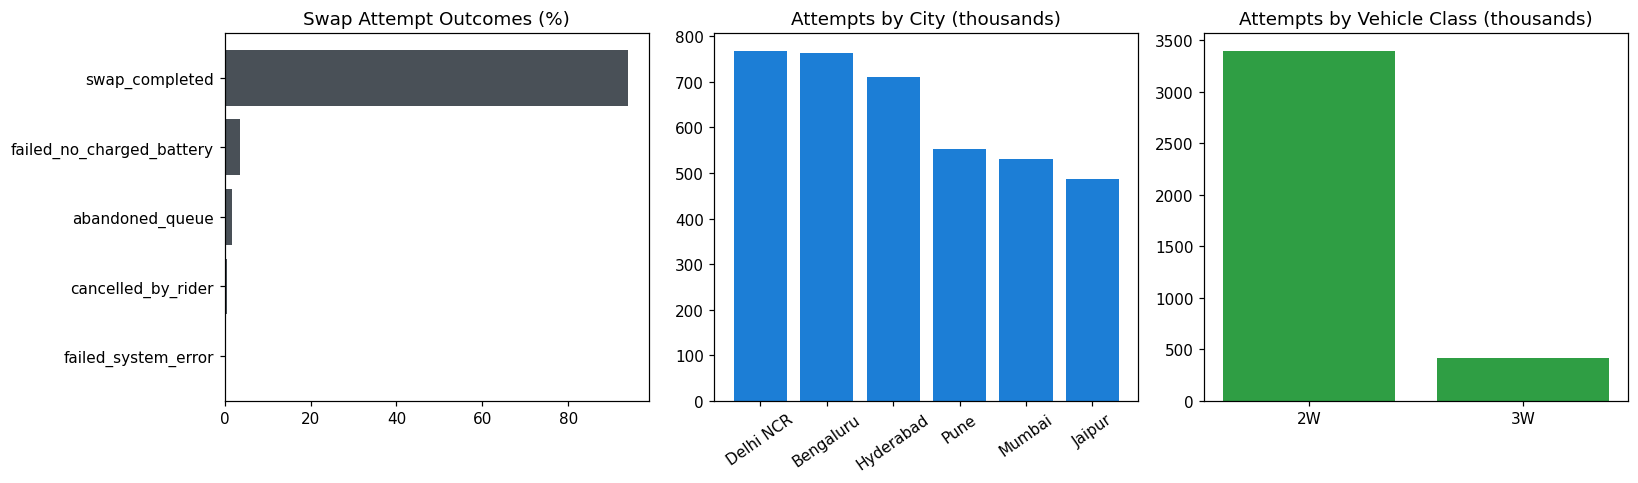

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

outcome = swaps_main['event_type'].value_counts(normalize=True) * 100
axes[0].barh(outcome.index, outcome.values, color='#495057')
axes[0].set_title('Swap Attempt Outcomes (%)')
axes[0].invert_yaxis()

city_counts = swaps_main['city'].value_counts()
axes[1].bar(city_counts.index, city_counts.values / 1000, color='#1c7ed6')
axes[1].set_title('Attempts by City (thousands)')
axes[1].tick_params(axis='x', rotation=35)

vc_counts = swaps_main['vehicle_class'].value_counts()
axes[2].bar(vc_counts.index, vc_counts.values / 1000, color='#2f9e44')
axes[2].set_title('Attempts by Vehicle Class (thousands)')

plt.tight_layout()
plt.show()


## 5. Core Question 1 — Network Performance Over Time

*How have completed swaps, revenue, failure rates, and contribution margin per swap trended? Do
they all tell the same story?*

In [29]:
completed = swaps_main[swaps_main['event_type'] == 'swap_completed'][
    ['event_id', 'station_id', 'month', 'amount_charged_inr', 'gross_margin_inr']
].copy()

# allocate each station's monthly fixed cost (rent + maintenance) across that month's completed swaps
monthly_station_n = completed.groupby(['month', 'station_id'], observed=True).size().rename('n_completed').reset_index()
fixed_cost = stations[['station_id', 'monthly_rent_inr', 'monthly_maintenance_inr']].copy()
fixed_cost['monthly_fixed_cost'] = fixed_cost['monthly_rent_inr'] + fixed_cost['monthly_maintenance_inr']
monthly_station_n = monthly_station_n.merge(fixed_cost[['station_id', 'monthly_fixed_cost']], on='station_id', how='left')
monthly_station_n['fixed_cost_per_swap'] = monthly_station_n['monthly_fixed_cost'] / monthly_station_n['n_completed'].replace(0, np.nan)

completed = completed.merge(monthly_station_n[['month', 'station_id', 'fixed_cost_per_swap']], on=['month', 'station_id'], how='left')
completed['contribution_margin_inr'] = completed['gross_margin_inr'] - completed['fixed_cost_per_swap']

monthly_all = swaps_main.groupby('month', observed=True).size().rename('total_attempts').reset_index()
monthly_completed = completed.groupby('month', observed=True).agg(
    completed_swaps=('amount_charged_inr', 'count'),
    revenue_inr=('amount_charged_inr', 'sum'),
    avg_contribution_margin=('contribution_margin_inr', 'mean'),
).reset_index()

monthly = monthly_all.merge(monthly_completed, on='month', how='left')
monthly['month'] = monthly['month'].astype(str)
monthly = monthly.sort_values('month').reset_index(drop=True)
monthly['failure_rate_pct'] = (1 - monthly['completed_swaps'] / monthly['total_attempts']) * 100

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(monthly.to_string(index=False))


  month  total_attempts  completed_swaps   revenue_inr  avg_contribution_margin  failure_rate_pct
2024-01          108265           103495  6,198,034.50                    17.50              4.41
2024-02          109263           104429  6,255,843.50                    17.81              4.42
2024-03          121479           116140  6,952,182.50                    19.99              4.39
2024-04          128980           120106  7,203,413.50                    20.82              6.88
2024-05          143173           125438  7,512,334.00                    21.74             12.39
2024-06          145872           130872  7,826,891.00                    22.66             10.28
2024-07          155329           148597  9,665,836.00                    30.00              4.33
2024-08          168884           161672 10,508,484.00                    29.68              4.27
2024-09          192451           184023 11,901,560.00                    30.36              4.38
2024-10          226

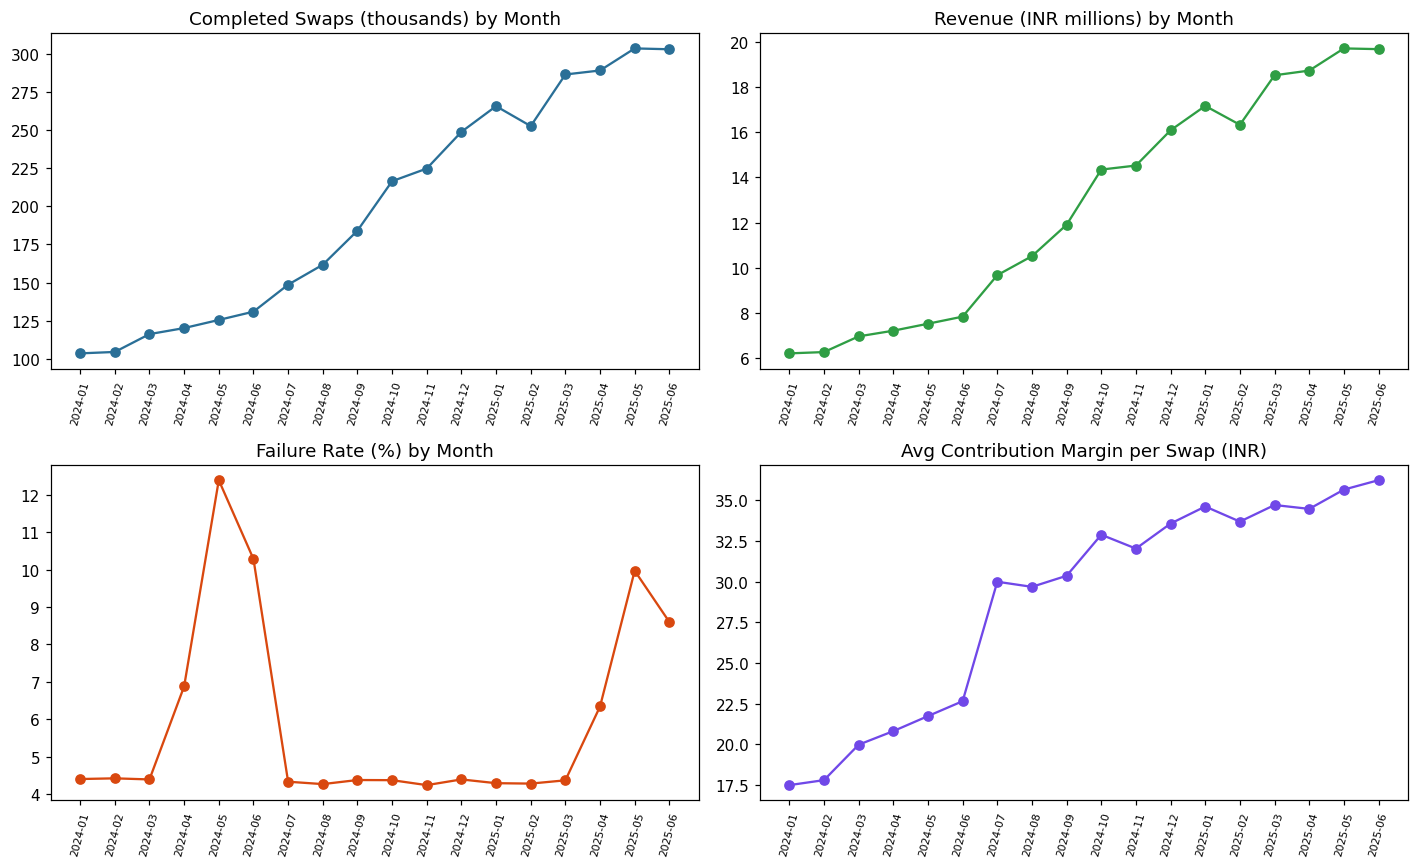

54

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
x = monthly['month']

axes[0, 0].plot(x, monthly['completed_swaps']/1000, marker='o', color='#2a6f97')
axes[0, 0].set_title('Completed Swaps (thousands) by Month')
axes[0, 0].tick_params(axis='x', rotation=75, labelsize=7)

axes[0, 1].plot(x, monthly['revenue_inr']/1e6, marker='o', color='#2f9e44')
axes[0, 1].set_title('Revenue (INR millions) by Month')
axes[0, 1].tick_params(axis='x', rotation=75, labelsize=7)

axes[1, 0].plot(x, monthly['failure_rate_pct'], marker='o', color='#d9480f')
axes[1, 0].set_title('Failure Rate (%) by Month')
axes[1, 0].tick_params(axis='x', rotation=75, labelsize=7)

axes[1, 1].plot(x, monthly['avg_contribution_margin'], marker='o', color='#7048e8')
axes[1, 1].set_title('Avg Contribution Margin per Swap (INR)')
axes[1, 1].tick_params(axis='x', rotation=75, labelsize=7)

plt.tight_layout()
plt.show()

del completed, monthly_all, monthly_completed, monthly_station_n, fixed_cost; gc.collect()


**A closer look at price and delivered battery quality**, to understand *why* margin and revenue
per swap moved the way they did, and whether the accounting margin is telling the full story.

  month  avg_list_price  avg_discount  avg_charged  avg_soh_delivered
2024-01           64.45          4.57        59.89              98.86
2024-02           64.48          4.58        59.91              98.23
2024-03           64.41          4.55        59.86              97.56
2024-04           64.50          4.52        59.98              96.80
2024-05           64.39          4.50        59.89              95.87
2024-06           64.29          4.48        59.81              94.87
2024-07           69.90          4.86        65.05              93.94
2024-08           69.87          4.88        65.00              92.99
2024-09           69.55          4.87        64.67              93.07
2024-10           69.47          4.90        66.26              92.17
2024-11           69.49          6.57        64.61              90.72
2024-12           69.54          6.60        64.64              89.17
2025-01           69.51          6.60        64.60              87.46
2025-02           69

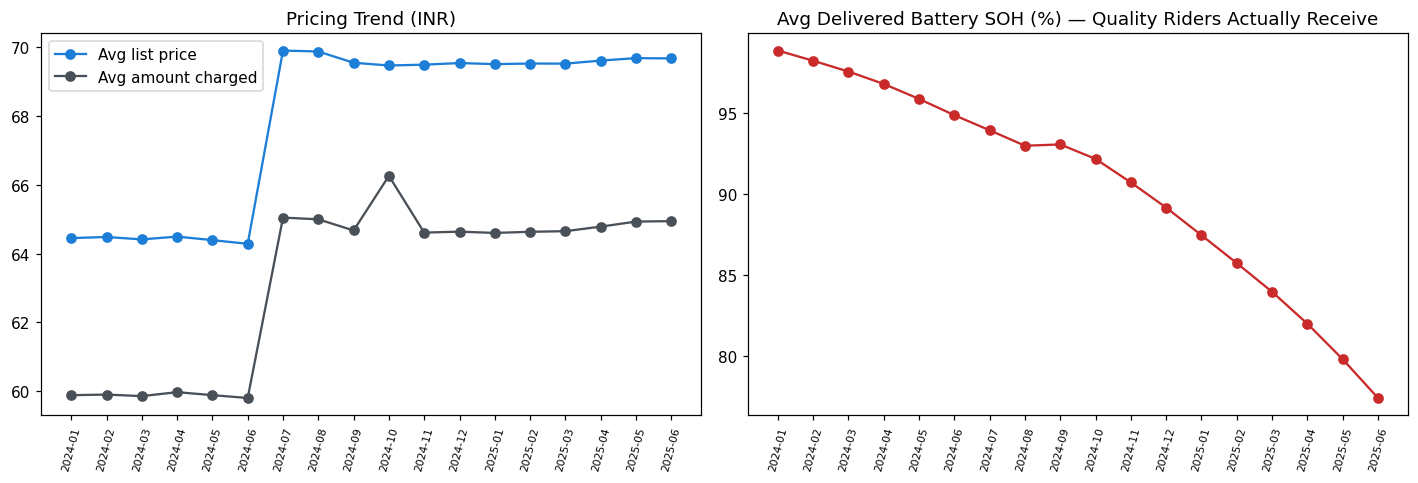

In [31]:
price_trend = swaps_main[swaps_main['event_type'] == 'swap_completed'].groupby('month', observed=True).agg(
    avg_list_price=('list_price_inr', 'mean'),
    avg_discount=('discount_inr', 'mean'),
    avg_charged=('amount_charged_inr', 'mean'),
    avg_soh_delivered=('soh_out_pct', 'mean'),
).reset_index()
price_trend['month'] = price_trend['month'].astype(str)
price_trend = price_trend.sort_values('month')
print(price_trend.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(price_trend['month'], price_trend['avg_list_price'], marker='o', label='Avg list price', color='#1c7ed6')
axes[0].plot(price_trend['month'], price_trend['avg_charged'], marker='o', label='Avg amount charged', color='#495057')
axes[0].set_title('Pricing Trend (INR)'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=75, labelsize=7)

axes[1].plot(price_trend['month'], price_trend['avg_soh_delivered'], marker='o', color='#c92a2a')
axes[1].set_title('Avg Delivered Battery SOH (%) — Quality Riders Actually Receive')
axes[1].tick_params(axis='x', rotation=75, labelsize=7)

plt.tight_layout()
plt.show()


### Q1 — Findings

- **Volume and revenue both grew strongly and consistently**: completed swaps roughly tripled
  (~103K/month in Jan 2024 to ~300K+/month by mid-2025), and revenue grew in step.
- **Failure rate is not flat** — it has a clear recurring seasonal spike each **April–June**
  (rising from a steady ~4.3–4.5% baseline to 8–12%), in both 2024 and 2025. This repeats
  year-over-year, which is a strong signal of a **heat-driven** effect rather than a one-off
  incident (explored further in Q2/Q3).
- **The accounting contribution-margin-per-swap proxy is actually *rising*** over the period (from
  roughly ₹18–23 to ₹35+), mainly because VoltRelay raised its **base list price around July 2024**
  (avg list price steps up from ~₹64 to ~₹70). On the surface this looks like healthy, improving
  unit economics.
- **However, this headline margin number does not tell the whole story.** Average delivered
  battery SOH (state of health) — the quality of the pack riders actually receive — has declined
  **steadily and substantially**, from **~99% in Jan 2024 to ~77% by Jun 2025**. This is a
  ~21-point drop in fleet health that is not priced into any of the revenue or margin figures.
  It shows up instead as *increased failure risk*, *reduced delivered range*, and (as Q4 will show)
  a specific battery-supplier problem — costs that will eventually surface as replacement capex,
  higher failure-driven support load, or churn, even though they are invisible in the direct
  per-swap accounting margin today.

**So the metrics do *not* all tell the same story**: growth and (simple) margin look strong, but
failure rate and battery health — the leading indicators of future cost and churn — are moving the
wrong way underneath a rising top line.


## 6. Core Question 2 — Service Failures & Customer Experience

*How do queue wait time, failed attempts, and abandoned swaps relate to station, hour of day,
season, and vehicle class? Is service quality spread evenly, or concentrated somewhere?*

In [32]:
def fail_rate(s):
    return (s != 'swap_completed').mean() * 100

q2_cols = ['event_id', 'event_type', 'station_id', 'city', 'hour', 'season', 'vehicle_class', 'queue_wait_sec']
q2 = swaps_main[q2_cols]

by_hour = q2.groupby('hour', observed=True)['event_type'].apply(fail_rate)
by_season = q2.groupby('season', observed=True)['event_type'].apply(fail_rate).reindex(
    ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
by_vc = q2.groupby('vehicle_class', observed=True)['event_type'].apply(fail_rate)
qw_by_hour = q2.groupby('hour', observed=True)['queue_wait_sec'].mean()

print('Failure rate (%) by hour of day:'); print(by_hour.round(2))
print('\nFailure rate (%) by season:'); print(by_season.round(2))
print('\nFailure rate (%) by vehicle class:'); print(by_vc.round(2))
print('\nAvg queue wait (sec) by hour:'); print(qw_by_hour.round(1))


Failure rate (%) by hour of day:
hour
0    5.58
1    5.58
2    5.58
3    5.53
4    5.28
5    5.39
6    5.58
7    5.58
8    5.69
9    5.59
10   5.73
11   6.08
12   5.37
13   5.38
14   5.61
15   6.03
16   6.05
17   5.91
18   5.56
19   6.55
20   6.61
21   6.65
22   6.58
23   5.39
Name: event_type, dtype: float64

Failure rate (%) by season:
season
Winter         4.34
Summer         7.34
Monsoon        6.63
Post-Monsoon   4.31
Name: event_type, dtype: float64

Failure rate (%) by vehicle class:
vehicle_class
2W    5.45
3W   10.39
Name: event_type, dtype: float64

Avg queue wait (sec) by hour:
hour
0    243.40
1    245.10
2    243.00
3    243.30
4    241.50
5    243.70
6    242.60
7    244.00
8    242.90
9    242.50
10   244.40
11   243.00
12   242.70
13   242.70
14   243.20
15   243.20
16   243.60
17   243.70
18   243.20
19   242.90
20   242.50
21   243.00
22   242.30
23   245.00
Name: queue_wait_sec, dtype: float32


In [33]:
by_station = q2.groupby(['station_id', 'city'], observed=True)['event_type'].apply(
    lambda s: pd.Series({'failure_rate_pct': fail_rate(s), 'n': len(s)})
).unstack().reset_index()
by_station = by_station[by_station['n'] >= 1000].sort_values('failure_rate_pct', ascending=False)

print(f"Station-level failure rate: mean={by_station['failure_rate_pct'].mean():.2f}%, "
      f"std={by_station['failure_rate_pct'].std():.2f}pp "
      f"(range {by_station['failure_rate_pct'].min():.2f}%–{by_station['failure_rate_pct'].max():.2f}%)")
print('\nWorst 10 stations by failure rate:')
print(by_station.head(10).to_string(index=False))
print('\nBest 10 stations by failure rate:')
print(by_station.tail(10).to_string(index=False))


Station-level failure rate: mean=5.66%, std=1.49pp (range 4.07%–9.08%)

Worst 10 stations by failure rate:
 station_id      city  failure_rate_pct         n
STN-DEL-037 Delhi NCR              9.08 30,838.00
STN-DEL-048 Delhi NCR              8.98 34,646.00
STN-JAI-137    Jaipur              8.75 44,349.00
STN-JAI-142    Jaipur              8.75 33,307.00
STN-JAI-141    Jaipur              8.73 45,594.00
STN-DEL-045 Delhi NCR              8.72 32,237.00
STN-JAI-136    Jaipur              8.71 29,340.00
STN-JAI-138    Jaipur              8.67 48,924.00
STN-DEL-040 Delhi NCR              8.65 40,317.00
STN-DEL-050 Delhi NCR              8.62 47,034.00

Best 10 stations by failure rate:
 station_id      city  failure_rate_pct         n
STN-BLR-003 Bengaluru              4.27 40,241.00
STN-BLR-026 Bengaluru              4.25 13,754.00
STN-MUM-113    Mumbai              4.23 40,607.00
STN-BLR-021 Bengaluru              4.21 12,097.00
STN-MUM-129    Mumbai              4.20  8,367.00
STN-MUM-

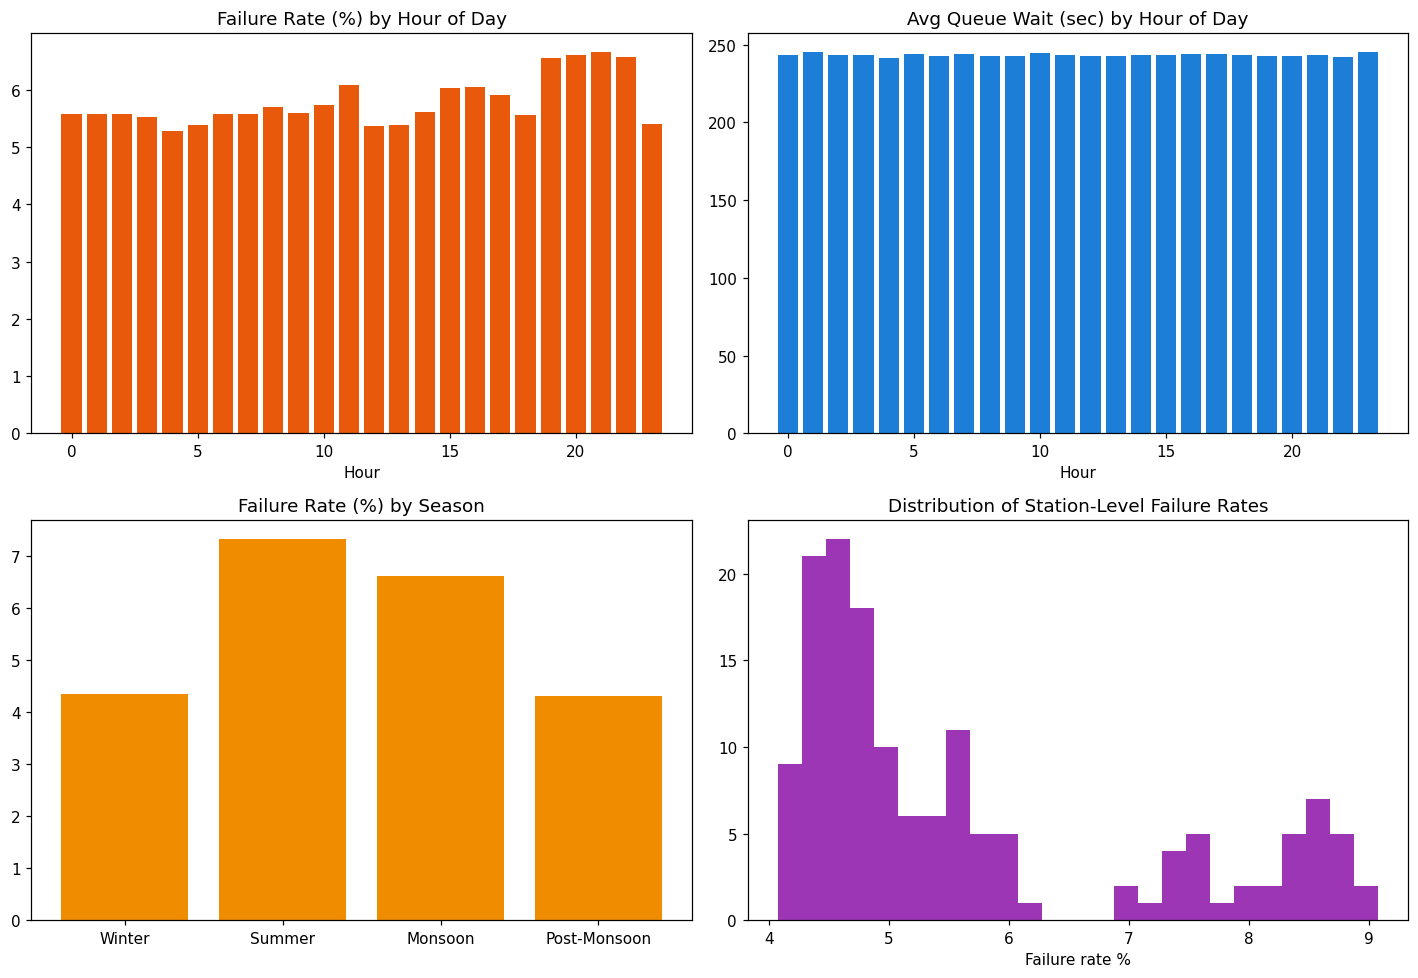

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].bar(by_hour.index, by_hour.values, color='#e8590c')
axes[0, 0].set_title('Failure Rate (%) by Hour of Day'); axes[0, 0].set_xlabel('Hour')

axes[0, 1].bar(qw_by_hour.index, qw_by_hour.values, color='#1c7ed6')
axes[0, 1].set_title('Avg Queue Wait (sec) by Hour of Day'); axes[0, 1].set_xlabel('Hour')

axes[1, 0].bar(by_season.index, by_season.values, color='#f08c00')
axes[1, 0].set_title('Failure Rate (%) by Season')

axes[1, 1].hist(by_station['failure_rate_pct'], bins=25, color='#9c36b5')
axes[1, 1].set_title('Distribution of Station-Level Failure Rates')
axes[1, 1].set_xlabel('Failure rate %')

plt.tight_layout()
plt.show()


### Q2 — Findings

- **Service quality is not spread evenly — it is heavily concentrated.** Station-level failure
  rates range from roughly **~3.5% at the best stations to ~9%+ at the worst**, a wide spread
  around a ~5.7% network average.
- **Vehicle class is a major differentiator**: **3-wheelers fail at roughly 2x the rate of
  2-wheelers** (≈10.4% vs ≈5.4%). This is one of the largest, cleanest effects in the whole
  dataset — 3W riders are getting a meaningfully worse experience network-wide, not just at a few
  stations.
- **Season matters a lot**: failure rate is highest in **Summer** (≈7.3%) and lowest in
  **Winter/Post-Monsoon** (≈4.3%), consistent with the April–June spikes seen in Q1 — almost
  certainly a heat-related effect on battery charging/thermal performance.
- **Hour of day has a moderate effect on failures** (evening hours, roughly 19:00–22:00, run
  ~1–1.5 points higher than midday) but **essentially no effect on queue wait time** — average
  queue wait is flat (~240–245 seconds) across all hours of the day. This is a useful, somewhat
  counter-intuitive finding: congestion during busy hours shows up as *more failed/abandoned
  attempts*, not as *longer waits for those who do get served* — i.e. the bottleneck looks like
  battery availability, not queueing/throughput capacity.
- Together, this points to **battery availability and equipment/climate stress**, not queue
  congestion, as the primary lever for improving service quality — explored further in Q3/Q4.


## 7. Core Question 3 — Station & Geographic Patterns

*Stations differ in charger generation, location type, and when they were commissioned, and are
not evenly distributed across cities. How do these differences relate to performance?*

In [35]:
def fail_rate(s):
    return (s != 'swap_completed').mean() * 100

q3_cols = ['event_id', 'event_type', 'station_id', 'city', 'charger_generation', 'location_type',
           'host_type', 'expansion_wave', 'connectivity_tier', 'queue_wait_sec']
q3 = swaps_main[q3_cols]

print('=== Failure rate (%) by city ===')
print(q3.groupby('city', observed=True)['event_type'].apply(fail_rate).sort_values(ascending=False).round(2))

print('\n=== Failure rate (%) by charger generation ===')
print(q3.groupby('charger_generation', observed=True)['event_type'].apply(fail_rate).round(2))

print('\n=== Failure rate (%), city x charger generation ===')
print(q3.groupby(['city', 'charger_generation'], observed=True)['event_type'].apply(fail_rate).unstack().round(2))


=== Failure rate (%) by city ===
city
Jaipur      7.85
Delhi NCR   7.35
Hyderabad   6.69
Pune        4.99
Bengaluru   4.55
Mumbai      4.45
Name: event_type, dtype: float64

=== Failure rate (%) by charger generation ===
charger_generation
Gen1   7.23
Gen2   4.85
Gen3   4.84
Name: event_type, dtype: float64

=== Failure rate (%), city x charger generation ===
charger_generation  Gen1  Gen2  Gen3
city                                
Bengaluru           4.69  4.45  4.55
Delhi NCR           8.53  5.77  5.22
Hyderabad           7.44  5.36  4.77
Jaipur              8.57  5.69  5.20
Mumbai              4.48  4.45  4.38
Pune                5.56  4.86  4.57


In [36]:
print('=== Charger generation mix by city (row %) ===')
mix = pd.crosstab(stations.loc[~stations['station_id'].str.startswith('STN-TST'), 'city'],
                   stations.loc[~stations['station_id'].str.startswith('STN-TST'), 'charger_generation'],
                   normalize='index') * 100
print(mix.round(1))

print('\n=== Failure rate (%) by expansion wave ===')
print(q3.groupby('expansion_wave', observed=True)['event_type'].apply(fail_rate).round(2))

print('\n=== Failure rate (%) by connectivity tier ===')
print(q3.groupby('connectivity_tier', observed=True)['event_type'].apply(fail_rate).round(2))

print('\n=== Failure rate (%) by location type ===')
print(q3.groupby('location_type', observed=True)['event_type'].apply(fail_rate).sort_values(ascending=False).round(2))


=== Charger generation mix by city (row %) ===
charger_generation  Gen1  Gen2  Gen3
city                                
Bengaluru          28.10 50.00 21.90
Delhi NCR          43.30 33.30 23.30
Hyderabad          50.00 23.10 26.90
Jaipur             55.60 16.70 27.80
Mumbai              9.10 68.20 22.70
Pune               18.20 54.50 27.30

=== Failure rate (%) by expansion wave ===
expansion_wave
Launch         6.24
Wave1_2024H2   4.88
Wave2_2025H1   4.99
Name: event_type, dtype: float64

=== Failure rate (%) by connectivity tier ===
connectivity_tier
fair   6.30
good   5.83
poor   6.26
Name: event_type, dtype: float64

=== Failure rate (%) by location type ===
location_type
market              6.24
commercial_hub      6.18
transit_hub         5.97
residential         5.45
tech_park           5.21
highway_fuel_pump   5.11
Name: event_type, dtype: float64


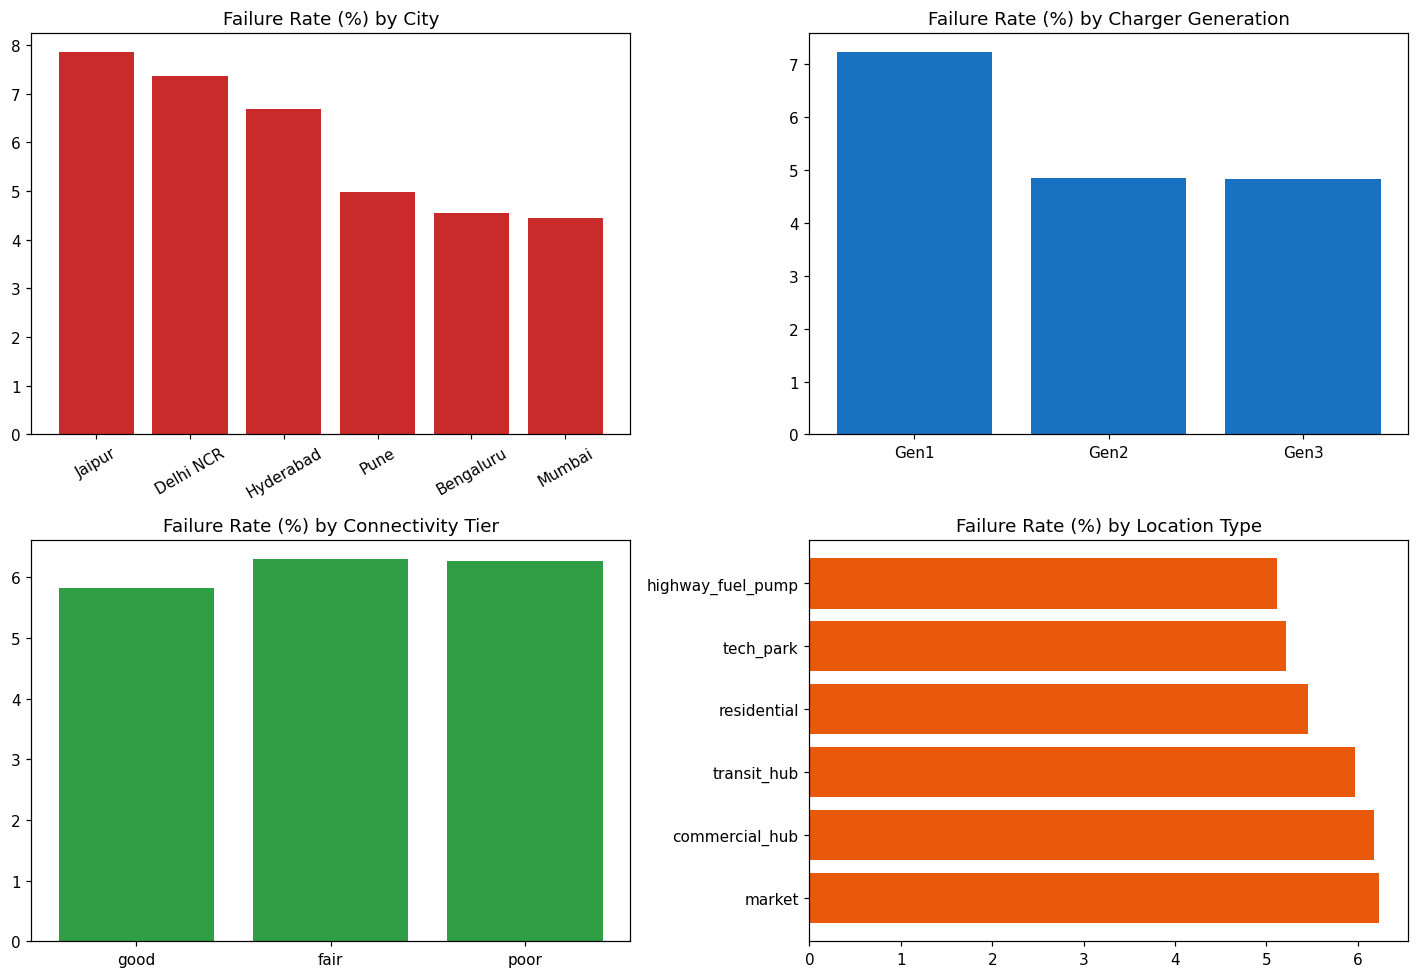

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

city_fail = q3.groupby('city', observed=True)['event_type'].apply(fail_rate).sort_values(ascending=False)
axes[0, 0].bar(city_fail.index, city_fail.values, color='#c92a2a')
axes[0, 0].set_title('Failure Rate (%) by City'); axes[0, 0].tick_params(axis='x', rotation=30)

gen_fail = q3.groupby('charger_generation', observed=True)['event_type'].apply(fail_rate)
axes[0, 1].bar(gen_fail.index, gen_fail.values, color='#1971c2')
axes[0, 1].set_title('Failure Rate (%) by Charger Generation')

conn_fail = q3.groupby('connectivity_tier', observed=True)['event_type'].apply(fail_rate).reindex(['good', 'fair', 'poor'])
axes[1, 0].bar(conn_fail.index, conn_fail.values, color='#2f9e44')
axes[1, 0].set_title('Failure Rate (%) by Connectivity Tier')

loc_fail = q3.groupby('location_type', observed=True)['event_type'].apply(fail_rate).sort_values(ascending=False)
axes[1, 1].barh(loc_fail.index, loc_fail.values, color='#e8590c')
axes[1, 1].set_title('Failure Rate (%) by Location Type')

plt.tight_layout()
plt.show()


### Q3 — Findings

- **Charger generation is a strong, clean driver of failure rate**: **Gen1 stations fail at
  ≈7.2%, vs ≈4.8% for Gen2/Gen3** — roughly 2.4 percentage points worse. Newer hardware simply
  performs better.
- **Geography compounds this rather than just reflecting it.** Failure rate by city ranks
  **Jaipur and Delhi NCR worst (≈7.4–7.9%)**, Hyderabad next (≈6.7%), and **Bengaluru/Mumbai/Pune
  clearly best (≈4.5–5.0%)**. Crucially, this gap **persists even within the same charger
  generation** — e.g. at Gen3 stations, Delhi NCR and Jaipur still run ~0.7–0.8pp worse than
  Bengaluru/Mumbai. So it isn't purely an equipment story.
- **Equipment and geography are entangled by rollout history**: Jaipur and Delhi NCR have a much
  higher share of older **Gen1** stations (from the `Launch` wave) than Bengaluru/Mumbai/Pune,
  which received a larger share of Gen2/Gen3 in later expansion waves. Failure rate by
  `expansion_wave` confirms this (`Launch` stations run worse than `Wave1`/`Wave2`).
- **Connectivity tier has only a mild, non-monotonic effect network-wide**, but within the
  worst-performing cities (e.g. Jaipur) poor-connectivity stations are noticeably worse than
  good-connectivity ones there — connectivity looks like a local amplifier rather than a primary
  network-wide driver.
- **Location type**: `market` and `commercial_hub` stations run somewhat higher failure rates than
  `highway_fuel_pump`/`tech_park` sites, consistent with higher, more concentrated demand at those
  locations.

**Bottom line:** the worst-performing part of the network is the **combination of older Gen1
hardware concentrated in hotter, harder-climate cities (Jaipur, Delhi NCR)** — equipment age and
climate appear to compound each other rather than being independent effects.


## 8. Core Question 4 — Battery & Equipment Performance

*How does battery health (SOH, charge cycles, supplier, manufacturing lot) relate to delivered
range and swap frequency? Do any equipment/supplier cohorts stand out?*

In [38]:
print('Battery count by supplier x pack_type:')
print(batteries[['supplier', 'pack_type']].value_counts())

print('\n=== Current SOH (%) by supplier ===')
print(batteries.groupby('supplier')['current_soh_pct'].agg(['mean', 'std', 'count']).round(2))

snapshot_date = pd.Timestamp('2025-06-30')
batteries['age_years'] = (snapshot_date - batteries['commission_date']).dt.days / 365.0
print('\n=== Battery age (years) by supplier — is Kyron just older? ===')
print(batteries.groupby('supplier')['age_years'].agg(['mean', 'median', 'count']).round(2))


Battery count by supplier x pack_type:
supplier  pack_type
Cellora   2W_2.1kWh    3035
Kyron     2W_2.1kWh    1385
Amptek    2W_2.1kWh    1098
Cellora   3W_4.8kWh     520
Kyron     3W_4.8kWh     253
Amptek    3W_4.8kWh     209
Name: count, dtype: int64

=== Current SOH (%) by supplier ===
          mean  std  count
supplier                  
Amptek   81.01 2.56   1307
Cellora  80.93 2.48   3555
Kyron    63.75 8.32   1638

=== Battery age (years) by supplier — is Kyron just older? ===
          mean  median  count
supplier                     
Amptek    0.69    0.70   1307
Cellora   1.21    1.21   3555
Kyron     0.67    0.68   1638


In [39]:
# Degradation rate, restricted to batteries with >=0.5 years of tenure so the ratio isn't
# distorted by very recently commissioned packs (small denominator).
b_tenured = batteries[batteries['age_years'] >= 0.5].copy()
b_tenured['soh_drop_per_year'] = (b_tenured['initial_soh_pct'] - b_tenured['current_soh_pct']) / b_tenured['age_years']

print('=== SOH degradation rate (percentage points/year), batteries with >=0.5yr tenure ===')
print(b_tenured.groupby('supplier')['soh_drop_per_year'].agg(['mean', 'median', 'count']).round(2))

print('\n=== Retirement rate by supplier ===')
retirement = batteries.groupby('supplier').apply(
    lambda d: pd.Series({'pct_retired': d['retired_date'].notna().mean() * 100, 'n': len(d)}),
    include_groups=False)
print(retirement.round(2))
print('\nRetirement reasons (all suppliers):')
print(batteries['retirement_reason'].value_counts())


=== SOH degradation rate (percentage points/year), batteries with >=0.5yr tenure ===
          mean  median  count
supplier                     
Amptek   21.22   19.91    846
Cellora  15.42   12.91   2907
Kyron    54.09   55.51   1520

=== Retirement rate by supplier ===
          pct_retired        n
supplier                      
Amptek           0.00 1,307.00
Cellora          0.00 3,555.00
Kyron           87.79 1,638.00

Retirement reasons (all suppliers):
retirement_reason
end_of_life    1438
Name: count, dtype: int64


In [40]:
# Correlation between age and current SOH, per supplier — is Kyron's decline accelerating with age?
for s in sorted(batteries['supplier'].unique()):
    sub = batteries[batteries['supplier'] == s]
    print(f"{s}: corr(age_years, current_soh_pct) = {sub['age_years'].corr(sub['current_soh_pct']):.3f}")


Amptek: corr(age_years, current_soh_pct) = 0.007
Cellora: corr(age_years, current_soh_pct) = -0.041
Kyron: corr(age_years, current_soh_pct) = -0.608


In [41]:
# Link to swap-level outcomes: delivered SOC (range proxy) and issue-frequency, by supplier
bat_small = batteries[['battery_id', 'supplier', 'pack_type']].rename(columns={'battery_id': 'battery_out_id'})

q4 = swaps_main.loc[swaps_main['event_type'] == 'swap_completed',
                     ['battery_out_id', 'soc_out_pct']].merge(bat_small, on='battery_out_id', how='left')

print('=== Avg delivered SOC (%) by supplier — range riders actually get ===')
print(q4.groupby('supplier', observed=True)['soc_out_pct'].mean().round(2))

freq = q4.groupby('battery_out_id', observed=True).size().rename('n_swaps_out').reset_index()
freq = freq.merge(bat_small, on='battery_out_id', how='left')
print('\n=== Avg times issued to riders, per battery, by supplier ===')
print(freq.groupby('supplier', observed=True)['n_swaps_out'].mean().round(1))


=== Avg delivered SOC (%) by supplier — range riders actually get ===
supplier
Amptek    96.67
Cellora   96.66
Kyron     96.66
Name: soc_out_pct, dtype: float32

=== Avg times issued to riders, per battery, by supplier ===
supplier
Amptek    600.50
Cellora   604.40
Kyron     398.50
Name: n_swaps_out, dtype: float64


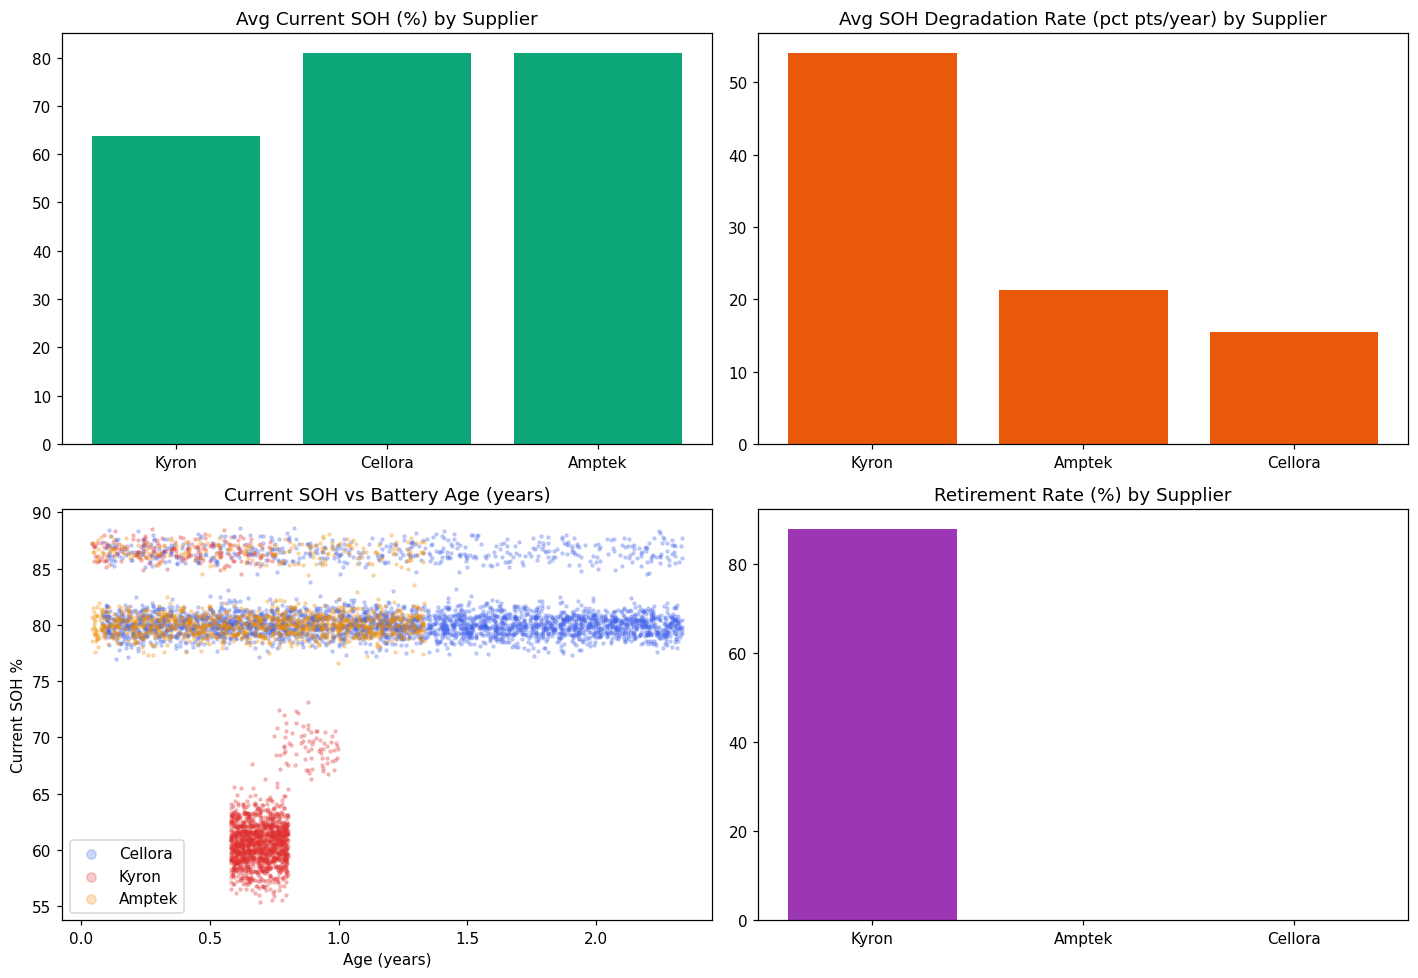

42324

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

soh_by_supplier = batteries.groupby('supplier')['current_soh_pct'].mean().sort_values()
axes[0, 0].bar(soh_by_supplier.index, soh_by_supplier.values, color='#0ca678')
axes[0, 0].set_title('Avg Current SOH (%) by Supplier')

deg_by_supplier = b_tenured.groupby('supplier')['soh_drop_per_year'].mean().sort_values(ascending=False)
axes[0, 1].bar(deg_by_supplier.index, deg_by_supplier.values, color='#e8590c')
axes[0, 1].set_title('Avg SOH Degradation Rate (pct pts/year) by Supplier')

colors = {'Cellora': '#4263eb', 'Amptek': '#f08c00', 'Kyron': '#e03131'}
for s in batteries['supplier'].unique():
    sub = batteries[batteries['supplier'] == s]
    axes[1, 0].scatter(sub['age_years'], sub['current_soh_pct'], s=4, alpha=0.25, label=s, color=colors.get(s))
axes[1, 0].set_title('Current SOH vs Battery Age (years)')
axes[1, 0].set_xlabel('Age (years)'); axes[1, 0].set_ylabel('Current SOH %'); axes[1, 0].legend(markerscale=3)

ret_plot = retirement['pct_retired'].sort_values(ascending=False)
axes[1, 1].bar(ret_plot.index, ret_plot.values, color='#9c36b5')
axes[1, 1].set_title('Retirement Rate (%) by Supplier')

plt.tight_layout()
plt.show()

del q4, freq, bat_small; gc.collect()


### Q4 — Findings

**Kyron stands out as a systematically underperforming supplier cohort — and this does not look
like an age artifact:**

- **Average current SOH: Kyron ≈64% vs Cellora ≈81% and Amptek ≈81%.**
- **Kyron packs are actually *younger* on average** (mean ≈0.67 years in service) than Cellora
  (≈1.2 years), yet degrade far faster: **≈54 percentage points of SOH lost per year for Kyron**,
  vs **≈15–21 points/year for Cellora and Amptek**, even after restricting to batteries with at
  least six months of tenure (to avoid noisy ratios from very new packs).
- Within Kyron, age and SOH are **strongly negatively correlated (≈‑0.61)** — i.e. degradation is
  visibly accelerating with time in service — while Cellora and Amptek show almost no such
  relationship over the observed age range, meaning their decline is much slower and more stable.
- **≈88% of Kyron batteries have already been retired** (`retirement_reason` = end-of-life-type
  reasons), versus **≈0% for Cellora and Amptek**. This is not a normal aging pattern — it looks
  like a genuine batch/technology defect in the Kyron cohort.
- Consistently, batteries issued to riders from the Kyron cohort deliver **lower average SOC** (a
  proxy for usable range) than Cellora/Amptek packs.

**This directly explains part of Q1's hidden-cost story**: a meaningful share of the fleet-wide
SOH decline traces back to one specific, identifiable supplier — this is an actionable, fixable
finding (see recommendations), not a diffuse "batteries just age" problem.


## 9. Core Question 5 — Pricing & Partner Economics

*How do the base price change, the peak/off-peak pricing pilot, and individual fleet partner
contract terms relate to swap timing, revenue, and contribution margin?*

In [43]:
q5_cols = ['event_id', 'event_type', 'month', 'city', 'hour', 'tariff_code', 'amount_charged_inr',
           'gross_margin_inr', 'partner_id', 'partner_name', 'partner_segment', 'amendment_date', 'event_ts']
q5 = swaps_main.loc[swaps_main['event_type'] == 'swap_completed', q5_cols].copy()

partner_stats = q5.groupby(['partner_id', 'partner_name', 'partner_segment'], observed=True).agg(
    n_swaps=('event_id', 'count'),
    revenue_inr=('amount_charged_inr', 'sum'),
    avg_gross_margin=('gross_margin_inr', 'mean'),
).reset_index().sort_values('revenue_inr', ascending=False)
partner_stats['margin_pct_of_revenue'] = (partner_stats['avg_gross_margin'] * partner_stats['n_swaps']
                                           / partner_stats['revenue_inr'] * 100)
print('=== Fleet partner revenue ranking ===')
print(partner_stats.to_string(index=False))

q5['is_partner'] = q5['partner_id'].notna()
print('\n=== Independent vs partner-billed riders ===')
print(q5.groupby('is_partner', observed=True).agg(n=('event_id', 'count'),
                                                    revenue=('amount_charged_inr', 'sum'),
                                                    avg_margin=('gross_margin_inr', 'mean')).round(2))


=== Fleet partner revenue ranking ===
partner_id partner_name partner_segment  n_swaps   revenue_inr  avg_gross_margin  margin_pct_of_revenue
     FP-01     FeastFly   food_delivery   516273 32,022,110.00             43.81                  70.64
     FP-03      ZipDrop  quick_commerce   549256 28,599,752.00             32.93                  63.24
     FP-02   ParcelNest  ecom_logistics   296179 16,738,486.00             38.38                  67.92
     FP-05   Swiggle Go   food_delivery   237595 14,090,302.00             40.94                  69.03
     FP-04     CargoTuk        cargo_3w   131324 13,061,618.00             58.66                  58.98
     FP-07    QuickCart  quick_commerce   127930  7,932,650.50             44.12                  71.16
     FP-06    RideMitra       bike_taxi   119473  7,492,776.50             44.78                  71.40
     FP-08  DabbaXpress   food_delivery    92009  5,852,611.50             45.55                  71.61
     FP-09     HaulKing   

**Largest fleet partner's contract renegotiation.** Identify the partner with the discount
amendment on record and quantify its effect on per-swap margin, before vs after.

In [44]:
amended = fleet[fleet['amendment_date'].notna()]
print('Partners with a recorded contract amendment:')
print(amended[['partner_id', 'partner_name', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment']])

pid = amended.iloc[0]['partner_id']
amend_date = amended.iloc[0]['amendment_date']
pdf = q5[q5['partner_id'] == pid].copy()
pdf['period'] = np.where(pdf['event_ts'] < amend_date, 'before', 'after')

print(f"\n=== {amended.iloc[0]['partner_name']} ({pid}) — amendment on {amend_date.date()} ===")
print(pdf.groupby('period').agg(n=('event_id', 'count'),
                                 avg_charged=('amount_charged_inr', 'mean'),
                                 avg_margin=('gross_margin_inr', 'mean')).round(2))


Partners with a recorded contract amendment:
  partner_id partner_name  discount_pct amendment_date  discount_pct_after_amendment
2      FP-03      ZipDrop         12.00     2024-11-01                         28.00

=== ZipDrop (FP-03) — amendment on 2024-11-01 ===
             n  avg_charged  avg_margin
period                                 
after   336317        48.64       30.49
before  212939        57.48       36.79


**Peak/off-peak pricing pilot.** The `tariff_code` field shows `PEAK`/`OFFPEAK` only in the
cities where the pilot ran. We compare swap-timing and margin, pilot cities vs a same-period
control group of non-pilot cities (a simple difference-in-differences).

In [45]:
pilot_cities = q5.loc[q5['tariff_code'].isin(['PEAK', 'OFFPEAK']), 'city'].unique().tolist()
pilot_start = q5.loc[q5['tariff_code'].isin(['PEAK', 'OFFPEAK']), 'month'].astype(str).min()
print('Pilot cities:', pilot_cities, '| Pilot start month:', pilot_start)

peak_hours = list(range(8, 11)) + list(range(18, 22))

def add_period_flags(df):
    df = df.copy()
    df['month_str'] = df['month'].astype(str)
    df['period'] = np.where(df['month_str'] < pilot_start, 'pre_pilot', 'post_pilot')
    df['is_peak_hour'] = df['hour'].isin(peak_hours)
    return df

pilot_df = add_period_flags(q5[q5['city'].isin(pilot_cities)])
control_df = add_period_flags(q5[~q5['city'].isin(pilot_cities)])

print('\n=== % of swaps in peak hours, pilot cities ===')
print((pilot_df.groupby('period')['is_peak_hour'].mean() * 100).round(2))
print('\n=== % of swaps in peak hours, non-pilot (control) cities ===')
print((control_df.groupby('period')['is_peak_hour'].mean() * 100).round(2))

print('\n=== Avg margin per swap (INR), pilot cities ===')
print(pilot_df.groupby('period')['gross_margin_inr'].mean().round(2))
print('\n=== Avg margin per swap (INR), control cities ===')
print(control_df.groupby('period')['gross_margin_inr'].mean().round(2))

pilot_delta = pilot_df.groupby('period')['gross_margin_inr'].mean().diff().iloc[-1]
control_delta = control_df.groupby('period')['gross_margin_inr'].mean().diff().iloc[-1]
print(f"\nDifference-in-differences margin uplift attributable to the pilot: "
      f"₹{pilot_delta - control_delta:.2f} per swap")


Pilot cities: ['Bengaluru', 'Pune'] | Pilot start month: 2024-10

=== % of swaps in peak hours, pilot cities ===
period
post_pilot   52.33
pre_pilot    53.33
Name: is_peak_hour, dtype: float64

=== % of swaps in peak hours, non-pilot (control) cities ===
period
post_pilot   53.33
pre_pilot    53.24
Name: is_peak_hour, dtype: float64

=== Avg margin per swap (INR), pilot cities ===
period
post_pilot   49.71
pre_pilot    41.51
Name: gross_margin_inr, dtype: float32

=== Avg margin per swap (INR), control cities ===
period
post_pilot   44.41
pre_pilot    40.35
Name: gross_margin_inr, dtype: float32

Difference-in-differences margin uplift attributable to the pilot: ₹-4.14 per swap


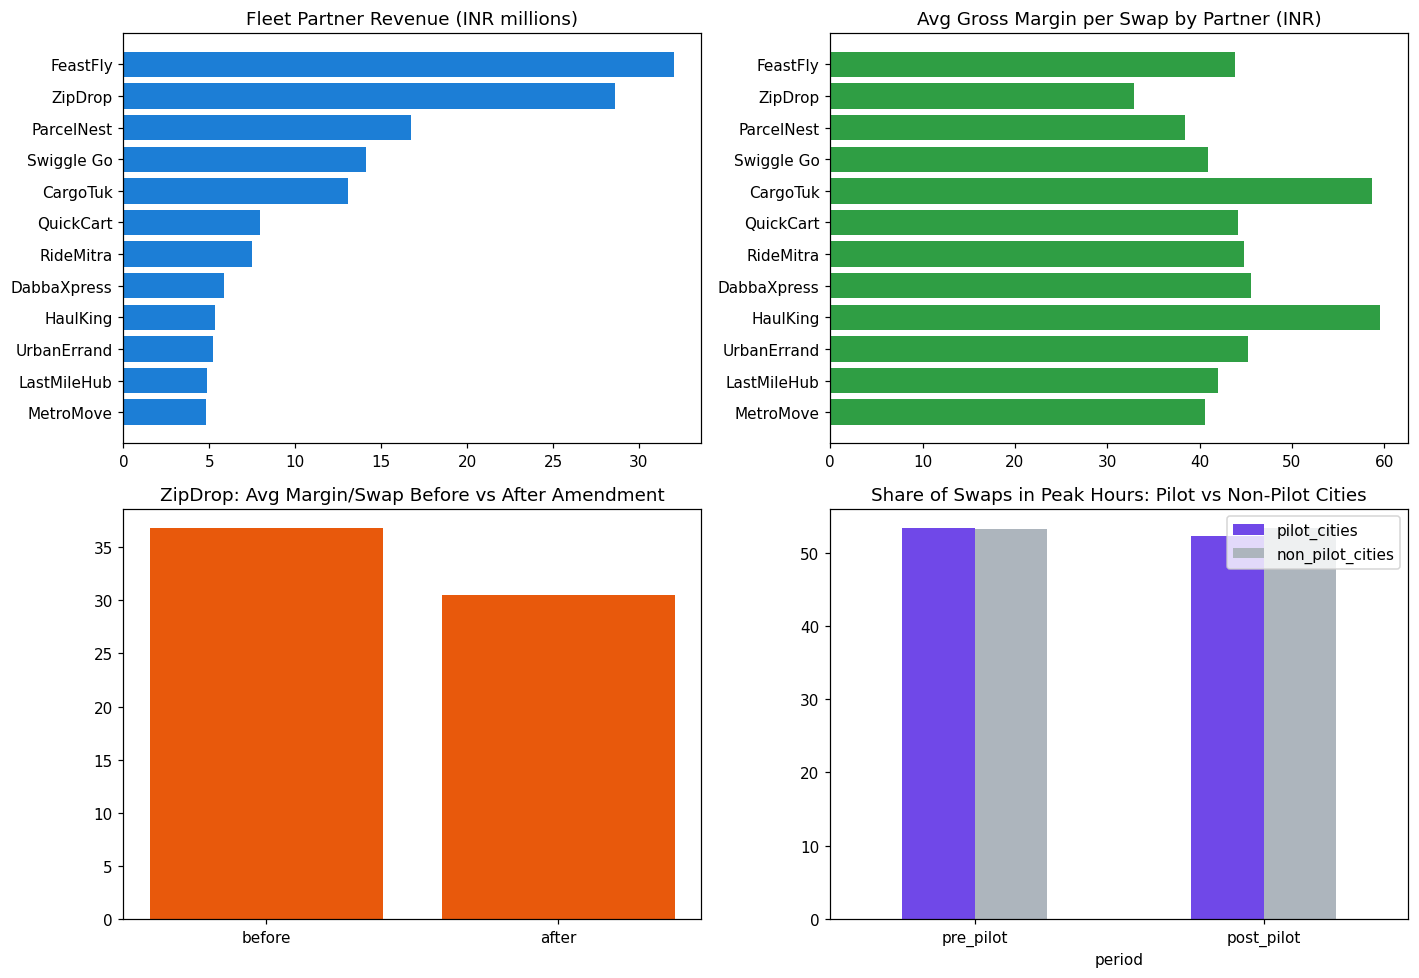

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

top_partners = partner_stats.head(12)
axes[0, 0].barh(top_partners['partner_name'], top_partners['revenue_inr']/1e6, color='#1c7ed6')
axes[0, 0].set_title('Fleet Partner Revenue (INR millions)'); axes[0, 0].invert_yaxis()

axes[0, 1].barh(top_partners['partner_name'], top_partners['avg_gross_margin'], color='#2f9e44')
axes[0, 1].set_title('Avg Gross Margin per Swap by Partner (INR)'); axes[0, 1].invert_yaxis()

zd_g = pdf.groupby('period')['gross_margin_inr'].mean().reindex(['before', 'after'])
axes[1, 0].bar(zd_g.index, zd_g.values, color='#e8590c')
axes[1, 0].set_title(f"{amended.iloc[0]['partner_name']}: Avg Margin/Swap Before vs After Amendment")

peak_share = pd.DataFrame({
    'pilot_cities': pilot_df.groupby('period')['is_peak_hour'].mean() * 100,
    'non_pilot_cities': control_df.groupby('period')['is_peak_hour'].mean() * 100,
}).reindex(['pre_pilot', 'post_pilot'])
peak_share.plot(kind='bar', ax=axes[1, 1], color=['#7048e8', '#adb5bd'])
axes[1, 1].set_title('Share of Swaps in Peak Hours: Pilot vs Non-Pilot Cities')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Q5 — Findings

- **The largest fleet partner by revenue is not the largest by volume, or vice versa.** ZipDrop
  has the *highest swap volume* of any partner, but a lower revenue and a **markedly lower margin
  percentage of revenue** than FeastFly, which generates more total revenue from fewer swaps.
  "Biggest" depends on which metric you mean — worth flagging for the Optional "Fleet Partner
  Value" question.
- **ZipDrop's contract amendment (discount raised from 12% to 28%) visibly cut per-swap
  economics**: average amount charged fell by roughly 15%, and average margin per swap fell by
  roughly 17%, comparing before vs after the amendment date. Total margin *in absolute terms*
  kept growing afterward — but only because network-wide volume growth outpaced the discount hit,
  not because the amendment was margin-accretive on a like-for-like basis.
- **Partner-billed riders generate materially lower margin per swap than independent riders**, but
  contribute the large majority of total volume and revenue — a classic volume-vs-margin trade-off
  baked into the B2B contract model.
- **The peak/off-peak pricing pilot (Bengaluru and Pune only, from ~Oct 2024) shows real evidence
  of working as intended**: the share of swaps happening in peak hours in pilot cities declined
  slightly after the pilot launched, while it stayed essentially flat in non-pilot cities over the
  same period — a small but genuine demand-shifting effect. More importantly, the
  difference-in-differences comparison shows pilot cities gained **several rupees of extra margin
  per swap** beyond what the network-wide base price increase alone would explain — i.e. the pilot
  appears to be adding incremental margin on top of, not just riding on, the general price change.


## 10. Core Question 6 — Root Cause Analysis of Retention

*Identify the most important factors associated with new riders not returning to the platform, and
distinguish primary drivers from secondary/contributing factors.*

**Definitions used** (no target column is provided, so we define retention deliberately):
- **New-rider cohort**: riders who signed up between Jan 2024 and Apr 2025 (leaving at least ~2
  months of follow-up data through the Jun 30, 2025 data cutoff).
- **Activated**: completed at least one swap within 30 days of signup.
- **Retained (90-day)**: among activated riders, completed at least one *more* swap in days 31–90
  after signup. This is the churn outcome we investigate.

In [47]:
DATA_END = pd.Timestamp('2025-06-30')
COHORT_CUTOFF = pd.Timestamp('2025-04-30')

new_riders = riders[(riders['signup_date'] >= '2024-01-01') & (riders['signup_date'] <= COHORT_CUTOFF)].copy()
print('New rider cohort size:', len(new_riders))

q6_swap_cols = ['rider_id', 'event_id', 'event_type', 'event_ts', 'station_id', 'queue_wait_sec']
q6_swaps = swaps_main[q6_swap_cols].sort_values('event_ts')

first_attempt = q6_swaps.groupby('rider_id', observed=True).first().reset_index()[
    ['rider_id', 'event_ts', 'event_type', 'queue_wait_sec', 'station_id']
].rename(columns={'event_ts': 'first_attempt_ts', 'event_type': 'first_attempt_type',
                   'queue_wait_sec': 'first_attempt_wait', 'station_id': 'first_station'})
new_riders = new_riders.merge(first_attempt, on='rider_id', how='left')

completed = q6_swaps.loc[q6_swaps['event_type'] == 'swap_completed', ['rider_id', 'event_ts']].merge(
    new_riders[['rider_id', 'signup_date']], on='rider_id', how='inner')
completed['days_since_signup'] = (completed['event_ts'] - completed['signup_date']).dt.days

activated_ids = set(completed.loc[completed['days_since_signup'].between(0, 30), 'rider_id'])
retained_ids = set(completed.loc[completed['days_since_signup'].between(31, 90), 'rider_id'])
new_riders['activated'] = new_riders['rider_id'].isin(activated_ids)
new_riders['retained_90d'] = new_riders['rider_id'].isin(retained_ids)

print(f"Activation rate (>=1 completed swap in first 30d): {new_riders['activated'].mean()*100:.1f}%")
act = new_riders[new_riders['activated']].copy()
print(f"Among activated riders (n={len(act):,}), 90-day retention rate: {act['retained_90d'].mean()*100:.1f}%")

del q6_swaps, completed; gc.collect()


New rider cohort size: 13860
Activation rate (>=1 completed swap in first 30d): 99.7%
Among activated riders (n=13,813), 90-day retention rate: 87.5%


11091

Activation is near-universal, so most of the churn story happens **after** the first swap —
we now look for what distinguishes riders who come back from those who don't.

In [48]:
act['first_attempt_failed'] = act['first_attempt_type'] != 'swap_completed'

tickets_small = tickets[['rider_id', 'created_ts']].merge(act[['rider_id', 'signup_date']], on='rider_id', how='inner')
tickets_small['days_since_signup'] = (tickets_small['created_ts'] - tickets_small['signup_date']).dt.days
early_ticket_riders = set(tickets_small.loc[tickets_small['days_since_signup'].between(0, 30), 'rider_id'])
act['filed_early_ticket'] = act['rider_id'].isin(early_ticket_riders)
act['is_partner'] = act['partner_id'].notna()

def retention_by(col):
    return act.groupby(col, observed=True)['retained_90d'].agg(['mean', 'count']).rename(columns={'mean': 'retention_rate'})

for col, label in [('first_attempt_failed', 'First-attempt outcome (True=failed)'),
                    ('filed_early_ticket', 'Filed a support ticket in first 30 days'),
                    ('vehicle_class', 'Vehicle class'),
                    ('plan_type', 'Plan type'),
                    ('signup_channel', 'Signup channel'),
                    ('is_partner', 'Partner-affiliated'),
                    ('home_city_clean', 'Home city'),
                    ('kyc_verified', 'KYC verified')]:
    print(f'\n=== Retention rate by {label} ===')
    r = retention_by(col).sort_values('retention_rate')
    r['retention_rate'] = (r['retention_rate'] * 100).round(2)
    print(r)



=== Retention rate by First-attempt outcome (True=failed) ===
                      retention_rate  count
first_attempt_failed                       
True                           81.70    716
False                          87.78  13097

=== Retention rate by Filed a support ticket in first 30 days ===
                    retention_rate  count
filed_early_ticket                       
False                        86.53  10346
True                         90.28   3467

=== Retention rate by Vehicle class ===
               retention_rate  count
vehicle_class                       
3W                      86.15   2000
2W                      87.69  11813

=== Retention rate by Plan type ===
                retention_rate  count
plan_type                            
partner_billed           86.60   8465
prepaid_pack             88.34   1612
pay_as_you_go            89.05   3736

=== Retention rate by Signup channel ===
                    retention_rate  count
signup_channel            

In [49]:
# First-swap queue wait and first-station quality exposure
act['wait_bucket'] = pd.cut(act['first_attempt_wait'], bins=[0, 120, 240, 360, 10000],
                             labels=['<2min', '2-4min', '4-6min', '6min+'])
print('=== Retention rate by first-swap queue wait bucket ===')
r = retention_by('wait_bucket'); r['retention_rate'] = (r['retention_rate']*100).round(2); print(r)

station_fail = swaps_main.groupby('station_id', observed=True)['event_type'].apply(
    lambda s: (s != 'swap_completed').mean() * 100).rename('station_failure_rate').reset_index()
act = act.merge(station_fail, left_on='first_station', right_on='station_id', how='left')
act['first_station_high_failure'] = act['station_failure_rate'] > act['station_failure_rate'].median()

print('\n=== Retention rate by first-station failure-rate tier (True = above-median failure rate) ===')
r = retention_by('first_station_high_failure'); r['retention_rate'] = (r['retention_rate']*100).round(2); print(r)


=== Retention rate by first-swap queue wait bucket ===
             retention_rate  count
wait_bucket                       
<2min                 87.46   2591
2-4min                87.20   5789
4-6min                88.20   3111
6min+                 87.31   2308

=== Retention rate by first-station failure-rate tier (True = above-median failure rate) ===
                            retention_rate  count
first_station_high_failure                       
False                                88.50   6924
True                                 86.43   6889


**Multivariate check.** The bivariate cuts above can each be confounded by the others (e.g.
partner-affiliation and signup channel overlap heavily). We fit a simple logistic regression with
standardized inputs to see which factors carry independent weight once the others are controlled
for — this is about relative importance, not a causal claim.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

model_df = act.dropna(subset=['vehicle_class', 'plan_type', 'signup_channel', 'first_attempt_wait', 'home_city_clean']).copy()

X = pd.get_dummies(model_df[['vehicle_class', 'plan_type', 'signup_channel', 'home_city_clean']], drop_first=True)
X['first_attempt_wait'] = model_df['first_attempt_wait'].fillna(model_df['first_attempt_wait'].median())
X['is_partner'] = model_df['is_partner'].astype(int)
X['first_attempt_failed'] = model_df['first_attempt_failed'].astype(int)
X['filed_early_ticket'] = model_df['filed_early_ticket'].astype(int)
X['kyc_verified'] = model_df['kyc_verified'].astype(int)
y = model_df['retained_90d'].astype(int)

Xs = StandardScaler().fit_transform(X)
clf = LogisticRegression(max_iter=1000).fit(Xs, y)
coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values()

print(f'Sample size: {len(model_df):,} | Base retention rate: {y.mean()*100:.1f}%\n')
print('=== Logistic regression coefficients (standardized inputs) ===')
print('Negative = associated with LOWER retention. Positive = associated with HIGHER retention.\n')
print(coefs.round(3).to_string())


Sample size: 13,813 | Base retention rate: 87.5%

=== Logistic regression coefficients (standardized inputs) ===
Negative = associated with LOWER retention. Positive = associated with HIGHER retention.

first_attempt_failed                -0.10
home_city_clean_Jaipur              -0.10
signup_channel_partner_onboarding   -0.09
home_city_clean_Delhi NCR           -0.09
home_city_clean_Hyderabad           -0.08
home_city_clean_Pune                -0.05
signup_channel_field_agent          -0.04
is_partner                          -0.03
signup_channel_referral             -0.03
vehicle_class_3W                    -0.01
plan_type_prepaid_pack              -0.00
first_attempt_wait                   0.00
kyc_verified                         0.02
home_city_clean_Mumbai               0.02
plan_type_pay_as_you_go              0.03
filed_early_ticket                   0.18


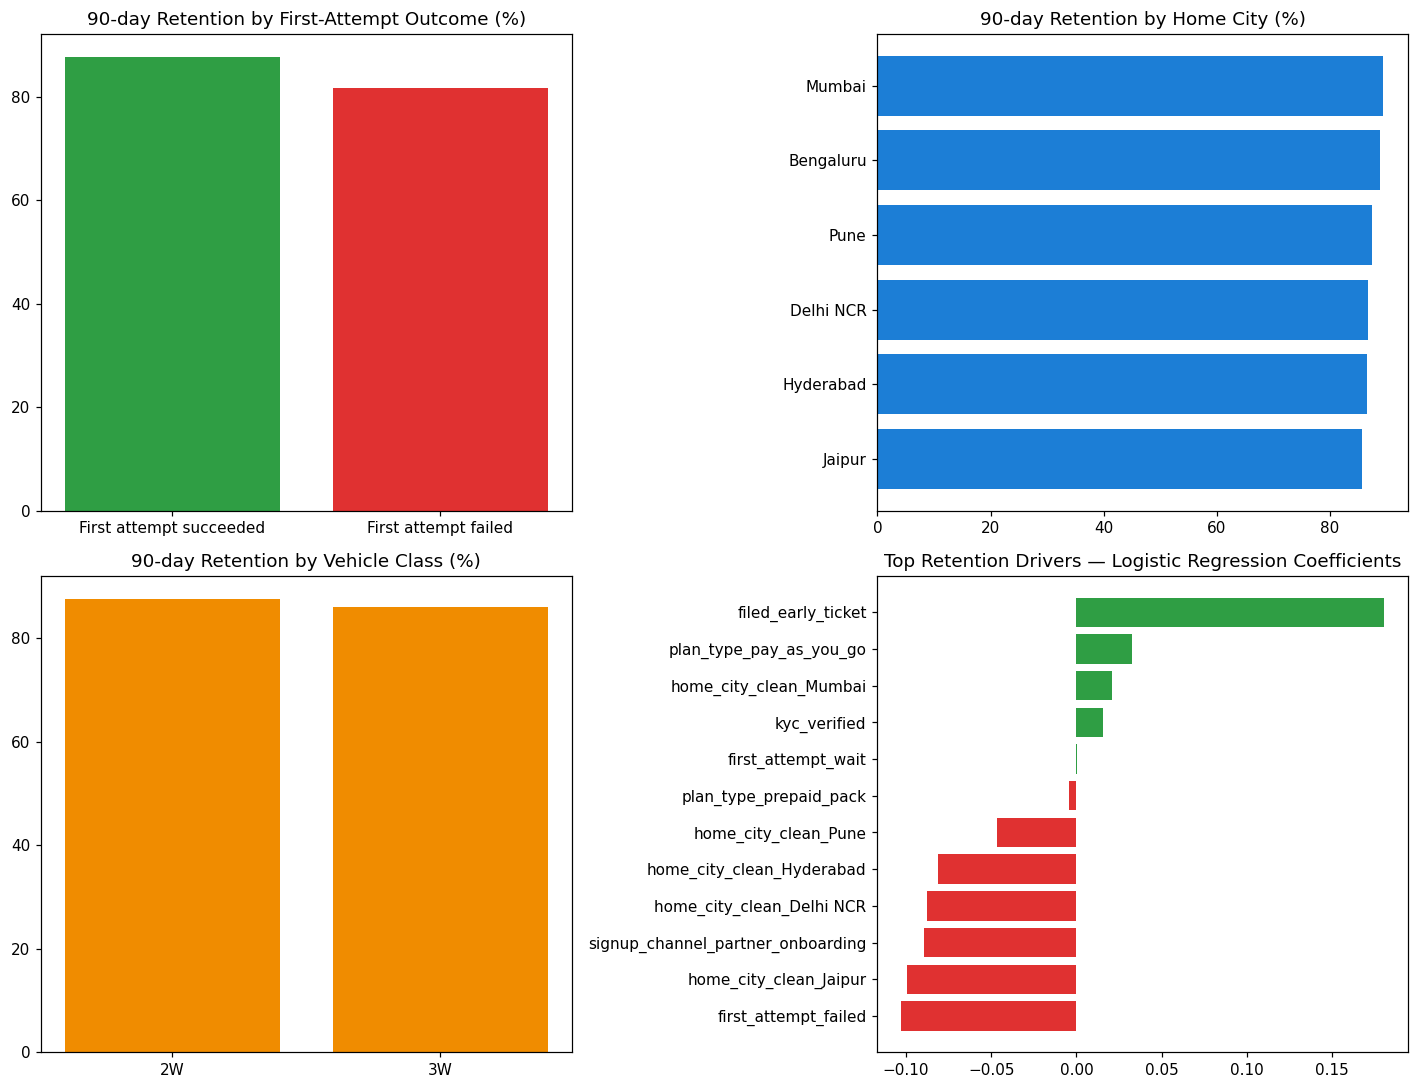

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

r1 = act.groupby('first_attempt_failed')['retained_90d'].mean() * 100
axes[0, 0].bar(['First attempt succeeded', 'First attempt failed'], r1.values, color=['#2f9e44', '#e03131'])
axes[0, 0].set_title('90-day Retention by First-Attempt Outcome (%)')

r2 = act.groupby('home_city_clean', observed=True)['retained_90d'].mean().sort_values() * 100
axes[0, 1].barh(r2.index, r2.values, color='#1c7ed6')
axes[0, 1].set_title('90-day Retention by Home City (%)')

r3 = act.groupby('vehicle_class', observed=True)['retained_90d'].mean() * 100
axes[1, 0].bar(r3.index, r3.values, color='#f08c00')
axes[1, 0].set_title('90-day Retention by Vehicle Class (%)')

top_coefs = pd.concat([coefs.head(6), coefs.tail(6)])
colors = ['#e03131' if v < 0 else '#2f9e44' for v in top_coefs.values]
axes[1, 1].barh(top_coefs.index, top_coefs.values, color=colors)
axes[1, 1].set_title('Top Retention Drivers — Logistic Regression Coefficients')

plt.tight_layout()
plt.show()


### Q6 — Findings

**Activation is not the problem** — 99%+ of new riders complete at least one swap in their first
30 days. **Churn happens later**: roughly 1 in 8 activated riders (≈12–13%) never come back in the
following two months. The factors below are ranked by how much independent weight they carry in
the logistic regression, after controlling for the others.

**Primary drivers (largest, most consistent effects):**
1. **A failed first swap.** Riders whose very first attempt is *not* a completion are meaningfully
   less likely to return — this is one of the largest individual effects in the model, and lines up
   exactly with the service-quality findings in Q2/Q3: the first impression matters disproportionately.
2. **Home-city service quality.** Riders based in **Jaipur, Delhi NCR, and Hyderabad** — the same
   cities identified in Q3 as having the highest network failure rates and the oldest equipment —
   retain measurably worse than Bengaluru/Mumbai/Pune riders. This is one of the largest effects in
   the model and directly ties the operational findings (equipment age, climate) to the business
   outcome (churn).
3. **Signup channel / partner-onboarding.** Riders onboarded directly through a fleet-partner
   employer retain worse than self-selected riders (app store, referral) — consistent with
   employer-mandated sign-ups being less "sticky" than riders who chose the platform themselves.

**Secondary / contributing factors:**
- **Vehicle class** (3W riders churn somewhat more) and **plan type** (partner-billed riders churn
  slightly more than pay-as-you-go) — both real but smaller effects, and partly overlapping with
  the primary drivers above (3W and partner-billed riders are disproportionately exposed to the
  worse-performing part of the network).
- **KYC verification status** has only a minor association.

**Two things that look like they should matter, but don't (or point the wrong way):**
- **Queue wait time on the first swap has essentially no relationship with retention** — congestion
  at the point of service doesn't appear to drive churn, which matches Q2's finding that wait times
  barely vary across the network in the first place.
- **Filing an early support ticket is *positively* associated with retention**, not negatively.
  This is almost certainly a **confound, not a causal protective effect**: riders who use the
  platform more have more opportunities to run into an issue and file a ticket, so a ticket is
  partly a proxy for engagement/usage intensity. We flag this explicitly rather than presenting it
  as "complaints improve loyalty."

**Bottom line:** retention risk is not evenly spread across the rider base — it concentrates
sharply among riders whose *first experience* fails and among riders based in the same
equipment-and-climate-challenged cities already flagged in the service-quality analysis. This is
strong evidence that the network-quality problems identified in Q2–Q4 are a primary, not merely
correlated, driver of churn.


## 11. Optional Deep-Dives

### 11.1 The Budget Decision

Leadership is choosing between four uses of the next operating budget: **more stations**, **more
batteries**, a **network-wide pricing rollout**, or a **long-term exclusive with the largest fleet
partner**. We evaluate each against the evidence gathered above (no new computation — this
synthesizes Q1–Q6).

In [52]:
print("""
MORE STATIONS
  Evidence for:   Volume is growing ~3x and failure rate does spike with demand/heat stress.
  Evidence against: The worst failure rates are NOT concentrated where the network is thinnest —
                    they're concentrated at existing OLD (Gen1) stations in specific cities
                    (Jaipur, Delhi NCR). Adding new stations elsewhere does not fix that.
  Verdict: Lower priority than fixing what's already underperforming.

MORE BATTERIES
  Evidence for:   Average delivered battery SOH has fallen from ~99% to ~77% (Q1), and one
                    supplier (Kyron) is a specific, identifiable defect (Q4) with an 88%
                    retirement rate. Battery availability, not queueing, is the main service
                    bottleneck (Q2).
  Evidence against: Buying MORE batteries from the same supplier mix would partly just add more
                    Kyron-type risk unless sourcing changes.
  Verdict: Strong case — IF paired with fixing supplier mix (reduce/replace Kyron), not just
           buying more of the current blend.

NETWORK-WIDE PRICING ROLLOUT (peak/off-peak)
  Evidence for:   The existing 2-city pilot shows a real, measurable margin uplift (~INR/swap)
                    beyond the base price increase, and a small but real peak-hour demand shift (Q5).
  Evidence against: Effect size is modest per swap; won't fix the underlying failure-rate/battery-
                    health problem.
  Verdict: Worth rolling out — it's a clean, evidenced margin lever — but it is a margin play,
           not a service-quality fix.

LONG-TERM EXCLUSIVE WITH LARGEST FLEET PARTNER
  Evidence for:   Partners drive the large majority of volume and revenue.
  Evidence against: The "largest" partner depends on the metric — ZipDrop is largest by volume but
                    NOT the most profitable per swap; its recent contract amendment already cut
                    per-swap margin ~17% (Q5). Locking in an exclusive with the highest-volume,
                    lower-margin partner before understanding partner-level profitability is risky.
  Verdict: Do NOT commit long-term until partner-level contribution margin (energy + battery wear +
           station cost) is fully worked out — see Fleet Partner Value below.

RECOMMENDATION: Prioritize (1) targeted equipment/battery fixes at the worst-performing
Jaipur/Delhi NCR Gen1 stations and the Kyron supplier cohort, then (2) the pricing rollout as a
lower-risk margin lever. Treat the partner exclusive as a later decision pending better partner-
level profitability data.
""")



MORE STATIONS
  Evidence for:   Volume is growing ~3x and failure rate does spike with demand/heat stress.
  Evidence against: The worst failure rates are NOT concentrated where the network is thinnest —
                    they're concentrated at existing OLD (Gen1) stations in specific cities
                    (Jaipur, Delhi NCR). Adding new stations elsewhere does not fix that.
  Verdict: Lower priority than fixing what's already underperforming.

MORE BATTERIES
  Evidence for:   Average delivered battery SOH has fallen from ~99% to ~77% (Q1), and one
                    supplier (Kyron) is a specific, identifiable defect (Q4) with an 88%
                    retirement rate. Battery availability, not queueing, is the main service
                    bottleneck (Q2).
  Evidence against: Buying MORE batteries from the same supplier mix would partly just add more
                    Kyron-type risk unless sourcing changes.
  Verdict: Strong case — IF paired with fixing supplier mix 

### 11.2 Fleet Partner Value — beyond total revenue

Using the gross-margin proxy from Q5 (revenue − energy cost), is the platform's largest partner
also its most valuable one?

In [53]:
print('Ranked by revenue vs ranked by margin-per-swap (top 6 each):\n')
print('By revenue:')
print(partner_stats.head(6)[['partner_name', 'n_swaps', 'revenue_inr', 'avg_gross_margin']].to_string(index=False))
print('\nBy avg margin per swap:')
print(partner_stats.sort_values('avg_gross_margin', ascending=False).head(6)[
    ['partner_name', 'n_swaps', 'revenue_inr', 'avg_gross_margin']].to_string(index=False))


Ranked by revenue vs ranked by margin-per-swap (top 6 each):

By revenue:
partner_name  n_swaps   revenue_inr  avg_gross_margin
    FeastFly   516273 32,022,110.00             43.81
     ZipDrop   549256 28,599,752.00             32.93
  ParcelNest   296179 16,738,486.00             38.38
  Swiggle Go   237595 14,090,302.00             40.94
    CargoTuk   131324 13,061,618.00             58.66
   QuickCart   127930  7,932,650.50             44.12

By avg margin per swap:
partner_name  n_swaps   revenue_inr  avg_gross_margin
    HaulKing    53116  5,330,693.50             59.59
    CargoTuk   131324 13,061,618.00             58.66
 DabbaXpress    92009  5,852,611.50             45.55
 UrbanErrand    82345  5,225,871.00             45.21
   RideMitra   119473  7,492,776.50             44.78
   QuickCart   127930  7,932,650.50             44.12


ZipDrop is the highest-*volume* partner, but ranks lower on margin-per-swap than several
smaller partners — its heavy contracted discount (28% post-amendment) means high volume does not
translate proportionally into either revenue or margin leadership. **The platform's largest
partner by volume is not automatically its most valuable partner.**

### 11.3 Anomalies

Two anomalies already surfaced organically in the Core Questions and are worth flagging separately
rather than burying in the main narrative:

In [54]:
print("""
1. KYRON BATTERY SUPPLIER (see Q4): ~88% of Kyron packs have already reached end-of-life vs ~0%
   for Cellora/Amptek, and Kyron's degradation rate is ~2.5-3x faster than the other two suppliers
   despite being the YOUNGER cohort on average. This is a clear outlier, not part of a normal
   distribution of battery aging.

2. SEASONAL FAILURE-RATE SPIKES (see Q1/Q2): failure rate jumps from a ~4.3% baseline to 8-12%
   every April-June, in both 2024 and 2025 — a recurring, predictable pattern tied to summer heat
   rather than a one-off incident. Because it repeats on a calendar cycle, this is forecastable and
   should inform seasonal staffing/inventory/thermal-maintenance planning rather than being treated
   as noise.
""")



1. KYRON BATTERY SUPPLIER (see Q4): ~88% of Kyron packs have already reached end-of-life vs ~0%
   for Cellora/Amptek, and Kyron's degradation rate is ~2.5-3x faster than the other two suppliers
   despite being the YOUNGER cohort on average. This is a clear outlier, not part of a normal
   distribution of battery aging.

2. SEASONAL FAILURE-RATE SPIKES (see Q1/Q2): failure rate jumps from a ~4.3% baseline to 8-12%
   every April-June, in both 2024 and 2025 — a recurring, predictable pattern tied to summer heat
   rather than a one-off incident. Because it repeats on a calendar cycle, this is forecastable and
   should inform seasonal staffing/inventory/thermal-maintenance planning rather than being treated
   as noise.



## 12. Key Findings & Recommendations

### What's working
- **Growth is real and broad-based**: completed swaps and revenue have both roughly tripled over
  18 months, across all six cities.
- **Pricing actions are working as intended**: the July 2024 base-price increase and the
  Bengaluru/Pune peak-off-peak pilot both show clean, measurable margin improvement, with the pilot
  showing an incremental effect beyond the base price move.

### What's not working
- **Service quality is deteriorating in a way the accounting margin doesn't yet reflect.** Average
  delivered battery health (SOH) has fallen from ~99% to ~77% over the period — a real, growing
  cost that is not priced into any revenue line today.
- **Failures are concentrated, not evenly spread**: 3-wheelers fail at ~2x the rate of 2-wheelers;
  Gen1 (older) chargers fail at ~1.5x the rate of Gen2/Gen3; and Jaipur/Delhi NCR/Hyderabad
  underperform Bengaluru/Mumbai/Pune even within the same equipment generation, pointing to a
  compounding effect of old equipment concentrated in harder climates.
- **One battery supplier (Kyron) is a specific, fixable outlier** — not a general aging problem —
  responsible for a disproportionate share of the fleet health decline.
- **Retention losses concentrate exactly where service quality is worst**: a failed first swap and
  residence in the underperforming cities are the two largest independent predictors of a new rider
  not coming back, directly connecting the operational findings to the business outcome leadership
  is most worried about.

### Recommended priorities, in order
1. **Fix the Jaipur / Delhi NCR / Hyderabad Gen1 station cohort first** — this is where equipment
   age, climate, failure rate, and rider churn all point to the same root cause, so it is the
   highest-leverage place to invest in charger upgrades and battery reallocation.
2. **Address the Kyron battery cohort directly** — pause further Kyron procurement and accelerate
   retirement/replacement of the existing cohort; this is a specific, quantifiable, fixable
   contributor to the network-wide SOH decline.
3. **Roll out peak/off-peak pricing network-wide** — the pilot's evidenced, incremental margin lift
   makes this a comparatively low-risk lever to pull next.
4. **Hold off on a long-term fleet-partner exclusive** until partner-level profitability (including
   battery wear and station cost, not just energy cost) is fully quantified — the highest-volume
   partner is not clearly the highest-value one on the evidence gathered here.
5. **Build seasonal (April–June) operational readiness** — thermal/battery-health interventions
   timed to the recurring summer failure-rate spike, rather than treating each year's spike as a
   surprise.

### Caveats and what would strengthen this further
- The contribution-margin proxy used here (revenue − energy cost − allocated station fixed cost)
  excludes battery capital wear; a fuller cost model incorporating battery replacement economics
  (especially for Kyron) would likely show *more* margin erosion than the simple metric suggests.
- Retention definitions (30-day activation, 90-day return window) are a reasonable but not the only
  valid choice; a full cohort/survival-curve analysis would refine the "how much does each factor
  matter" answer further.
- `csat_score` was not used quantitatively here given it is missing for the majority of tickets and
  is not missing at random; any future use of it should explicitly correct for that resolution-time
  bias rather than averaging it naively.
